# Notebook 04 — Exploratory Data Analysis (EDA) & Insight Generation

## Objective
This notebook performs the core exploratory data analysis for the LA Traffic Collision Project.

The main goals are to:
- validate the final analytical inputs from Notebook 02 and Notebook 03
- understand the overall collision distribution across time, geography, victims, and collision context
- extract clear, business-readable analytical insights
- generate reusable tables and figures for reporting and dashboard design
- establish a reliable analytical baseline before aggregation, SQL preparation, and BI export layers

## Primary Input Files
From `data/cleaned/`:
- `collisions_clean.csv`
- `bridge_collision_mo.csv`
- `dim_mo_codes.csv`
- `dim_date.csv`
- `dim_area.csv`
- `dim_premise.csv`

## Expected Output Areas
- `outputs/tables/eda/`
- `outputs/figures/eda/`

## Methodology Note
This notebook follows a structured EDA workflow:
1. environment setup and path validation
2. loading analytical inputs
3. quick structural validation
4. progressive exploratory analysis by theme
5. insight capture and export of supporting outputs

In [1]:
# ============================================================
# Notebook 04 — Setup & Project Paths
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# basic display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Resolve project root safely
# ------------------------------------------------------------
# Expected notebook location:
# la_traffic_collision_project/notebooks/04_eda_core_analysis.ipynb
# So project root should be parent of current working directory if run from notebooks,
# or discovered from current path parts if run elsewhere.

cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
elif (cwd / "data").exists() and (cwd / "outputs").exists():
    PROJECT_ROOT = cwd
else:
    candidates = [cwd] + list(cwd.parents)
    PROJECT_ROOT = None
    for p in candidates:
        if (p / "data").exists() and (p / "outputs").exists() and (p / "notebooks").exists():
            PROJECT_ROOT = p
            break
    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "Could not locate project root. Please run the notebook from inside the project folder."
        )

# ------------------------------------------------------------
# Define key folders
# ------------------------------------------------------------
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_CLEANED = PROJECT_ROOT / "data" / "cleaned"

OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables" / "eda"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures" / "eda"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Define input files
# ------------------------------------------------------------
COLLISIONS_CLEAN_PATH = DATA_CLEANED / "collisions_clean.csv"
BRIDGE_MO_PATH = DATA_CLEANED / "bridge_collision_mo.csv"
DIM_MO_CODES_PATH = DATA_CLEANED / "dim_mo_codes.csv"
DIM_DATE_PATH = DATA_CLEANED / "dim_date.csv"
DIM_AREA_PATH = DATA_CLEANED / "dim_area.csv"
DIM_PREMISE_PATH = DATA_CLEANED / "dim_premise.csv"

required_files = {
    "collisions_clean": COLLISIONS_CLEAN_PATH,
    "bridge_collision_mo": BRIDGE_MO_PATH,
    "dim_mo_codes": DIM_MO_CODES_PATH,
    "dim_date": DIM_DATE_PATH,
    "dim_area": DIM_AREA_PATH,
    "dim_premise": DIM_PREMISE_PATH,
}

path_check = pd.DataFrame({
    "dataset_name": list(required_files.keys()),
    "path": [str(p) for p in required_files.values()],
    "exists": [p.exists() for p in required_files.values()],
})

print("=" * 70)
print("Notebook 04 Setup")
print("=" * 70)
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_CLEANED : {DATA_CLEANED}")
print(f"OUTPUT_TABLES: {OUTPUT_TABLES}")
print(f"OUTPUT_FIGURES: {OUTPUT_FIGURES}")
print("-" * 70)

display(path_check)

missing_files = path_check.loc[~path_check["exists"], "dataset_name"].tolist()
if missing_files:
    raise FileNotFoundError(
        f"Missing required input files: {missing_files}"
    )

print("-" * 70)
print("All required files are available. Setup completed successfully.")

Notebook 04 Setup
PROJECT_ROOT : C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project
DATA_CLEANED : C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\cleaned
OUTPUT_TABLES: C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda
OUTPUT_FIGURES: C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda
----------------------------------------------------------------------


,dataset_name,path,exists
0,collisions_clean,C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\cleaned\collisions_clean.csv,True
1,bridge_collision_mo,C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\cleaned\bridge_collision_mo.csv,True
2,dim_mo_codes,C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\cleaned\dim_mo_codes.csv,True
3,dim_date,C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\cleaned\dim_date.csv,True
4,dim_area,C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\cleaned\dim_area.csv,True
5,dim_premise,C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\cleaned\dim_premise.csv,True


----------------------------------------------------------------------
All required files are available. Setup completed successfully.


## Step 1 — Load Analytical Input Tables

In this step, we load the cleaned and modeled datasets prepared in the previous notebooks.

These datasets represent the analytical base for EDA:
- the cleaned collision-level table
- the collision-to-MO bridge table
- the classified MO dimension
- supporting dimensions for date, area, and premise

This step is important because it confirms that:
- the exported datasets are readable
- the expected core tables are available in memory
- the notebook is working on the correct analytical layer before starting structural validation

In [2]:
# ============================================================
# Step 1 — Load Analytical Input Tables
# ============================================================

df_collisions = pd.read_csv(COLLISIONS_CLEAN_PATH)
df_bridge_mo = pd.read_csv(BRIDGE_MO_PATH)
df_dim_mo = pd.read_csv(DIM_MO_CODES_PATH)
df_dim_date = pd.read_csv(DIM_DATE_PATH)
df_dim_area = pd.read_csv(DIM_AREA_PATH)
df_dim_premise = pd.read_csv(DIM_PREMISE_PATH)

loaded_tables_summary = pd.DataFrame({
    "table_name": [
        "df_collisions",
        "df_bridge_mo",
        "df_dim_mo",
        "df_dim_date",
        "df_dim_area",
        "df_dim_premise",
    ],
    "rows": [
        len(df_collisions),
        len(df_bridge_mo),
        len(df_dim_mo),
        len(df_dim_date),
        len(df_dim_area),
        len(df_dim_premise),
    ],
    "columns": [
        df_collisions.shape[1],
        df_bridge_mo.shape[1],
        df_dim_mo.shape[1],
        df_dim_date.shape[1],
        df_dim_area.shape[1],
        df_dim_premise.shape[1],
    ],
    "memory_mb_approx": [
        round(df_collisions.memory_usage(deep=True).sum() / 1024**2, 2),
        round(df_bridge_mo.memory_usage(deep=True).sum() / 1024**2, 2),
        round(df_dim_mo.memory_usage(deep=True).sum() / 1024**2, 2),
        round(df_dim_date.memory_usage(deep=True).sum() / 1024**2, 2),
        round(df_dim_area.memory_usage(deep=True).sum() / 1024**2, 2),
        round(df_dim_premise.memory_usage(deep=True).sum() / 1024**2, 2),
    ]
})

print("=" * 70)
print("Loaded Tables Summary")
print("=" * 70)
display(loaded_tables_summary)

print("\nSample columns from each table:\n")

table_columns_preview = {
    "df_collisions": df_collisions.columns.tolist()[:15],
    "df_bridge_mo": df_bridge_mo.columns.tolist()[:15],
    "df_dim_mo": df_dim_mo.columns.tolist()[:15],
    "df_dim_date": df_dim_date.columns.tolist()[:15],
    "df_dim_area": df_dim_area.columns.tolist()[:15],
    "df_dim_premise": df_dim_premise.columns.tolist()[:15],
}

for table_name, cols in table_columns_preview.items():
    print(f"{table_name}:")
    print(cols)
    print("-" * 70)

Loaded Tables Summary


,table_name,rows,columns,memory_mb_approx
0,df_collisions,621677,34,224.77
1,df_bridge_mo,3523096,5,229.12
2,df_dim_mo,337,13,0.12
3,df_dim_date,5546,7,0.42
4,df_dim_area,21,2,0.00
5,df_dim_premise,124,2,0.00



Sample columns from each table:

df_collisions:
['dr_number', 'date_reported', 'date_occurred', 'time_occurred', 'time_occurred_str', 'occ_hour', 'occ_minute', 'occ_time_of_day', 'occ_year', 'occ_month', 'occ_month_name', 'occ_weekday', 'occ_weekday_name', 'area_id', 'area_name']
----------------------------------------------------------------------
df_bridge_mo:
['dr_number', 'mo_codes', 'mo_code', 'mo_code_count_raw', 'has_valid_mo_code_format']
----------------------------------------------------------------------
df_dim_mo:
['mo_code', 'mo_description', 'analytical_category', 'analytical_subcategory', 'analytical_domain', 'code_family', 'primary_entity', 'dashboard_group', 'traffic_relevance_score', 'traffic_relevance_band', 'keep_in_main_collision_dashboard', 'modeling_role', 'recommended_use']
----------------------------------------------------------------------
df_dim_date:
['date_key', 'date', 'year', 'month', 'month_name', 'weekday', 'weekday_name']
-------------------------

## Step 2 — Structural Validation of Core Analytical Tables

Before starting the exploratory analysis, we validate the structural quality of the loaded tables.

This validation checks:
- table shapes
- column data types
- missing values in key analytical fields
- uniqueness of expected keys
- readiness of the core tables for reliable downstream analysis

This step is methodologically important because EDA results can become misleading if the analytical base contains hidden structural issues, invalid keys, or incomplete critical fields.

In [3]:
# ============================================================
# Step 2 — Structural Validation of Core Analytical Tables
# ============================================================

# -------------------------------
# 1) Data types overview
# -------------------------------
dtype_summary = pd.DataFrame({
    "column_name": df_collisions.columns,
    "dtype": df_collisions.dtypes.astype(str).values,
    "missing_count": df_collisions.isna().sum().values,
    "missing_pct": (df_collisions.isna().mean().values * 100).round(2)
}).sort_values(["missing_pct", "column_name"], ascending=[False, True]).reset_index(drop=True)

print("=" * 70)
print("df_collisions — Dtype & Missing Summary")
print("=" * 70)
display(dtype_summary.head(20))

# -------------------------------
# 2) Key uniqueness checks
# -------------------------------
validation_checks = []

validation_checks.append({
    "check_name": "df_collisions.dr_number_unique",
    "result": df_collisions["dr_number"].is_unique if "dr_number" in df_collisions.columns else False
})

validation_checks.append({
    "check_name": "df_dim_mo.mo_code_unique",
    "result": df_dim_mo["mo_code"].is_unique if "mo_code" in df_dim_mo.columns else False
})

validation_checks.append({
    "check_name": "df_dim_date.date_key_unique",
    "result": df_dim_date["date_key"].is_unique if "date_key" in df_dim_date.columns else False
})

validation_checks.append({
    "check_name": "df_dim_area.area_id_unique",
    "result": df_dim_area["area_id"].is_unique if "area_id" in df_dim_area.columns else False
})

validation_checks.append({
    "check_name": "df_dim_premise.premise_code_unique",
    "result": df_dim_premise["premise_code"].is_unique if "premise_code" in df_dim_premise.columns else False
})

validation_checks.append({
    "check_name": "df_bridge_mo_has_dr_number",
    "result": "dr_number" in df_bridge_mo.columns
})

validation_checks.append({
    "check_name": "df_bridge_mo_has_mo_code",
    "result": "mo_code" in df_bridge_mo.columns
})

validation_df = pd.DataFrame(validation_checks)

print("\n" + "=" * 70)
print("Key Structural Validation Checks")
print("=" * 70)
display(validation_df)

# -------------------------------
# 3) Missingness in critical EDA fields
# -------------------------------
critical_cols = [
    "dr_number",
    "date_occurred",
    "occ_year",
    "occ_month",
    "occ_weekday_name",
    "occ_hour",
    "area_id",
    "area_name",
    "premise_code",
    "premise_description",
    "victim_age",
    "victim_sex",
    "victim_descent",
    "latitude",
    "longitude",
]

critical_cols_existing = [c for c in critical_cols if c in df_collisions.columns]

critical_missing_summary = pd.DataFrame({
    "column_name": critical_cols_existing,
    "missing_count": [df_collisions[c].isna().sum() for c in critical_cols_existing],
    "missing_pct": [round(df_collisions[c].isna().mean() * 100, 2) for c in critical_cols_existing],
    "n_unique": [df_collisions[c].nunique(dropna=True) for c in critical_cols_existing],
})

critical_missing_summary = critical_missing_summary.sort_values(
    ["missing_pct", "column_name"], ascending=[False, True]
).reset_index(drop=True)

print("\n" + "=" * 70)
print("Critical EDA Fields — Missingness Summary")
print("=" * 70)
display(critical_missing_summary)

# -------------------------------
# 4) Save validation outputs
# -------------------------------
dtype_summary.to_csv(OUTPUT_TABLES / "eda_collisions_dtype_missing_summary.csv", index=False)
validation_df.to_csv(OUTPUT_TABLES / "eda_structural_validation_checks.csv", index=False)
critical_missing_summary.to_csv(OUTPUT_TABLES / "eda_critical_fields_missing_summary.csv", index=False)

print("\n" + "-" * 70)
print("Structural validation outputs saved to:")
print(OUTPUT_TABLES / "eda_collisions_dtype_missing_summary.csv")
print(OUTPUT_TABLES / "eda_structural_validation_checks.csv")
print(OUTPUT_TABLES / "eda_critical_fields_missing_summary.csv")

df_collisions — Dtype & Missing Summary


,column_name,dtype,missing_count,missing_pct
0,victim_age,float64,88194,14.19
1,mo_codes,str,87324,14.05
2,cross_street,str,29460,4.74
3,victim_descent,str,11651,1.87
4,victim_sex,str,10895,1.75
5,premise_code,float64,959,0.15
6,premise_description,str,960,0.15
7,address,str,0,0.00
8,area_id,int64,0,0.00
9,area_name,str,0,0.00



Key Structural Validation Checks


,check_name,result
0,df_collisions.dr_number_unique,True
1,df_dim_mo.mo_code_unique,True
2,df_dim_date.date_key_unique,True
3,df_dim_area.area_id_unique,True
4,df_dim_premise.premise_code_unique,True
5,df_bridge_mo_has_dr_number,True
6,df_bridge_mo_has_mo_code,True



Critical EDA Fields — Missingness Summary


,column_name,missing_count,missing_pct,n_unique
0,victim_age,88194,14.19,90
1,victim_descent,11651,1.87,19
2,victim_sex,10895,1.75,3
3,premise_code,959,0.15,125
4,premise_description,960,0.15,124
5,area_id,0,0.00,21
6,area_name,0,0.00,21
7,date_occurred,0,0.00,5546
8,dr_number,0,0.00,621677
9,latitude,0,0.00,5071



----------------------------------------------------------------------
Structural validation outputs saved to:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_collisions_dtype_missing_summary.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_structural_validation_checks.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_critical_fields_missing_summary.csv


## Step 3 — Final Type Refinement for EDA Readiness

Before starting the actual exploratory analysis, we perform a final data-type refinement step.

This step is especially important for:
- converting date fields from text format to proper datetime format
- validating that key time variables are analytically usable
- confirming that no date-parsing issues remain hidden in the dataset

This improves methodological reliability because time-based EDA should be performed on validated datetime fields rather than raw text representations.

In [4]:
# ============================================================
# Step 3 — Final Type Refinement for EDA Readiness
# ============================================================

df_eda = df_collisions.copy()

# -------------------------------
# Convert date columns to datetime
# -------------------------------
date_cols = ["date_occurred", "date_reported"]
date_conversion_results = []

for col in date_cols:
    if col in df_eda.columns:
        before_missing = df_eda[col].isna().sum()
        parsed = pd.to_datetime(df_eda[col], errors="coerce")
        after_missing = parsed.isna().sum()
        newly_failed = after_missing - before_missing
        
        df_eda[col] = parsed
        
        date_conversion_results.append({
            "column_name": col,
            "original_dtype": str(df_collisions[col].dtype),
            "new_dtype": str(df_eda[col].dtype),
            "missing_before": int(before_missing),
            "missing_after": int(after_missing),
            "new_parse_failures": int(newly_failed),
            "min_date": df_eda[col].min(),
            "max_date": df_eda[col].max(),
        })

date_conversion_summary = pd.DataFrame(date_conversion_results)

print("=" * 70)
print("Date Conversion Summary")
print("=" * 70)
display(date_conversion_summary)

# -------------------------------
# Confirm critical time columns
# -------------------------------
time_readiness_checks = []

for col in ["date_occurred", "date_reported", "occ_year", "occ_month", "occ_weekday_name", "occ_hour"]:
    time_readiness_checks.append({
        "column_name": col,
        "exists": col in df_eda.columns,
        "dtype": str(df_eda[col].dtype) if col in df_eda.columns else "MISSING",
        "missing_count": int(df_eda[col].isna().sum()) if col in df_eda.columns else None,
        "n_unique": int(df_eda[col].nunique(dropna=True)) if col in df_eda.columns else None,
    })

time_readiness_df = pd.DataFrame(time_readiness_checks)

print("\n" + "=" * 70)
print("EDA Time Readiness Check")
print("=" * 70)
display(time_readiness_df)

# -------------------------------
# Save outputs
# -------------------------------
date_conversion_summary.to_csv(OUTPUT_TABLES / "eda_date_conversion_summary.csv", index=False)
time_readiness_df.to_csv(OUTPUT_TABLES / "eda_time_readiness_check.csv", index=False)

print("\n" + "-" * 70)
print("Type refinement outputs saved to:")
print(OUTPUT_TABLES / "eda_date_conversion_summary.csv")
print(OUTPUT_TABLES / "eda_time_readiness_check.csv")

Date Conversion Summary


,column_name,original_dtype,new_dtype,missing_before,missing_after,new_parse_failures,min_date,max_date
0,date_occurred,str,datetime64[us],0,0,0,2010-01-01,2025-03-08
1,date_reported,str,datetime64[us],0,0,0,2010-01-01,2025-03-08



EDA Time Readiness Check


,column_name,exists,dtype,missing_count,n_unique
0,date_occurred,True,datetime64[us],0,5546
1,date_reported,True,datetime64[us],0,5546
2,occ_year,True,int64,0,16
3,occ_month,True,int64,0,12
4,occ_weekday_name,True,str,0,7
5,occ_hour,True,int64,0,24



----------------------------------------------------------------------
Type refinement outputs saved to:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_date_conversion_summary.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_time_readiness_check.csv


## Step 4 — Collision Overview KPIs

This section establishes the high-level analytical baseline of the collision dataset.

The purpose is to summarize:
- total collision volume
- temporal coverage
- geographic breadth
- premise coverage
- average collision intensity over time

These KPIs provide the first executive view of the analytical dataset before moving into deeper time, location, victim, and MO-based analysis.

In [5]:
# ============================================================
# Step 4 — Collision Overview KPIs
# ============================================================

overview_kpis = {
    "total_collisions": len(df_eda),
    "unique_dr_numbers": df_eda["dr_number"].nunique() if "dr_number" in df_eda.columns else np.nan,
    "date_min": df_eda["date_occurred"].min() if "date_occurred" in df_eda.columns else pd.NaT,
    "date_max": df_eda["date_occurred"].max() if "date_occurred" in df_eda.columns else pd.NaT,
    "covered_days": df_eda["date_occurred"].nunique() if "date_occurred" in df_eda.columns else np.nan,
    "covered_years": df_eda["occ_year"].nunique() if "occ_year" in df_eda.columns else np.nan,
    "unique_areas": df_eda["area_id"].nunique() if "area_id" in df_eda.columns else np.nan,
    "unique_area_names": df_eda["area_name"].nunique() if "area_name" in df_eda.columns else np.nan,
    "unique_premise_codes": df_eda["premise_code"].nunique(dropna=True) if "premise_code" in df_eda.columns else np.nan,
    "unique_premise_descriptions": df_eda["premise_description"].nunique(dropna=True) if "premise_description" in df_eda.columns else np.nan,
}

overview_kpis["avg_collisions_per_day"] = round(
    overview_kpis["total_collisions"] / overview_kpis["covered_days"], 2
) if overview_kpis["covered_days"] not in [0, np.nan] else np.nan

overview_kpis["avg_collisions_per_year"] = round(
    overview_kpis["total_collisions"] / overview_kpis["covered_years"], 2
) if overview_kpis["covered_years"] not in [0, np.nan] else np.nan

overview_kpis_df = pd.DataFrame({
    "metric": list(overview_kpis.keys()),
    "value": list(overview_kpis.values())
})

print("=" * 70)
print("Collision Overview KPIs")
print("=" * 70)
display(overview_kpis_df)

# optional compact printable version
print("\nExecutive Summary:")
for _, row in overview_kpis_df.iterrows():
    print(f"- {row['metric']}: {row['value']}")

# save
overview_kpis_df.to_csv(OUTPUT_TABLES / "eda_collision_overview_kpis.csv", index=False)

print("\n" + "-" * 70)
print("Saved to:")
print(OUTPUT_TABLES / "eda_collision_overview_kpis.csv")

Collision Overview KPIs


,metric,value
0,total_collisions,621677
1,unique_dr_numbers,621677
2,date_min,2010-01-01 00:00:00
3,date_max,2025-03-08 00:00:00
4,covered_days,5546
5,covered_years,16
6,unique_areas,21
7,unique_area_names,21
8,unique_premise_codes,125
9,unique_premise_descriptions,124



Executive Summary:
- total_collisions: 621677
- unique_dr_numbers: 621677
- date_min: 2010-01-01 00:00:00
- date_max: 2025-03-08 00:00:00
- covered_days: 5546
- covered_years: 16
- unique_areas: 21
- unique_area_names: 21
- unique_premise_codes: 125
- unique_premise_descriptions: 124
- avg_collisions_per_day: 112.09
- avg_collisions_per_year: 38854.81

----------------------------------------------------------------------
Saved to:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_collision_overview_kpis.csv


## Baseline Interpretation Note

The analytical base appears structurally reliable for exploratory analysis.

Key baseline observations:
- the dataset contains **621,677 collision records**
- each collision is uniquely represented at the `dr_number` level
- the analytical time coverage spans from **2010-01-01** to **2025-03-08**
- the dataset covers **21 geographic areas**
- premise coverage is broad, with more than 120 coded premise values
- the average collision volume is approximately **112 collisions per day**

Methodological note:
A small difference exists between the number of unique premise codes and unique premise descriptions. This is acceptable for EDA at this stage and likely reflects limited missing or partially unmapped premise metadata rather than a structural failure.

## Step 5 — Annual Collision Trend Analysis

This section examines how collision volume changes across years.

The goal is to:
- quantify the yearly collision trend
- identify broad rises, declines, or structural shifts over time
- establish the first time-based pattern in the dataset

This analysis is important because yearly trend movement provides a high-level temporal narrative before moving to monthly, weekday, and hourly patterns.

Annual Collision Trend Table


,occ_year,total_collisions,yoy_abs_change,yoy_pct_change
0,2010,45098,NaN,NaN
1,2011,45280,182.0,0.40
2,2012,45409,129.0,0.28
3,2013,45040,-369.0,-0.81
4,2014,46957,1917.0,4.26
5,2015,52488,5531.0,11.78
6,2016,56532,4044.0,7.70
7,2017,57727,1195.0,2.11
8,2018,57159,-568.0,-0.98
9,2019,56628,-531.0,-0.93


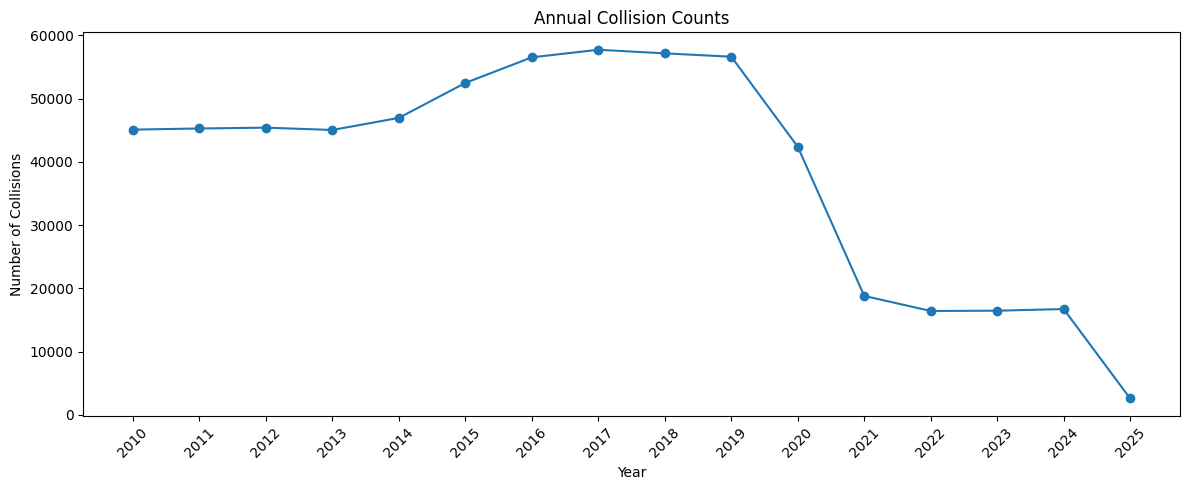


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_annual_collision_trend.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_annual_collision_trend.png


In [6]:
# ============================================================
# Step 5 — Annual Collision Trend Analysis
# ============================================================

annual_collisions = (
    df_eda.groupby("occ_year", as_index=False)
    .agg(total_collisions=("dr_number", "count"))
    .sort_values("occ_year")
    .reset_index(drop=True)
)

annual_collisions["yoy_abs_change"] = annual_collisions["total_collisions"].diff()
annual_collisions["yoy_pct_change"] = (
    annual_collisions["total_collisions"].pct_change() * 100
).round(2)

print("=" * 70)
print("Annual Collision Trend Table")
print("=" * 70)
display(annual_collisions)

# ------------------------------------------------------------
# Plot annual trend
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    annual_collisions["occ_year"],
    annual_collisions["total_collisions"],
    marker="o"
)

plt.title("Annual Collision Counts")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.xticks(annual_collisions["occ_year"], rotation=45)
plt.tight_layout()

annual_fig_path = OUTPUT_FIGURES / "eda_annual_collision_trend.png"
plt.savefig(annual_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------
annual_table_path = OUTPUT_TABLES / "eda_annual_collision_trend.csv"
annual_collisions.to_csv(annual_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(annual_table_path)
print(annual_fig_path)

## Step 5A — Annual Trend Refinement for Partial-Year Bias

The initial annual trend table includes 2025, but the dataset only extends to 2025-03-08.

This means that 2025 represents a **partial year**, not a full-year observation.
Therefore, it should not be interpreted directly against complete historical years.

To improve methodological validity, we create:
- a year-completeness flag
- a full-year-only annual trend table for fair historical comparison

This prevents misleading interpretation caused by partial-year truncation.

Year Coverage Summary


,occ_year,total_collisions,min_date,max_date,covered_days,is_full_year
0,2010,45098,2010-01-01,2010-12-31,365,True
1,2011,45280,2011-01-01,2011-12-31,365,True
2,2012,45409,2012-01-01,2012-12-31,366,True
3,2013,45040,2013-01-01,2013-12-31,365,True
4,2014,46957,2014-01-01,2014-12-31,365,True
5,2015,52488,2015-01-01,2015-12-31,365,True
6,2016,56532,2016-01-01,2016-12-31,366,True
7,2017,57727,2017-01-01,2017-12-31,365,True
8,2018,57159,2018-01-01,2018-12-31,365,True
9,2019,56628,2019-01-01,2019-12-31,365,True



Annual Trend — Full Years Only


,occ_year,total_collisions,yoy_abs_change,yoy_pct_change
0,2010,45098,NaN,NaN
1,2011,45280,182.0,0.40
2,2012,45409,129.0,0.28
3,2013,45040,-369.0,-0.81
4,2014,46957,1917.0,4.26
5,2015,52488,5531.0,11.78
6,2016,56532,4044.0,7.70
7,2017,57727,1195.0,2.11
8,2018,57159,-568.0,-0.98
9,2019,56628,-531.0,-0.93


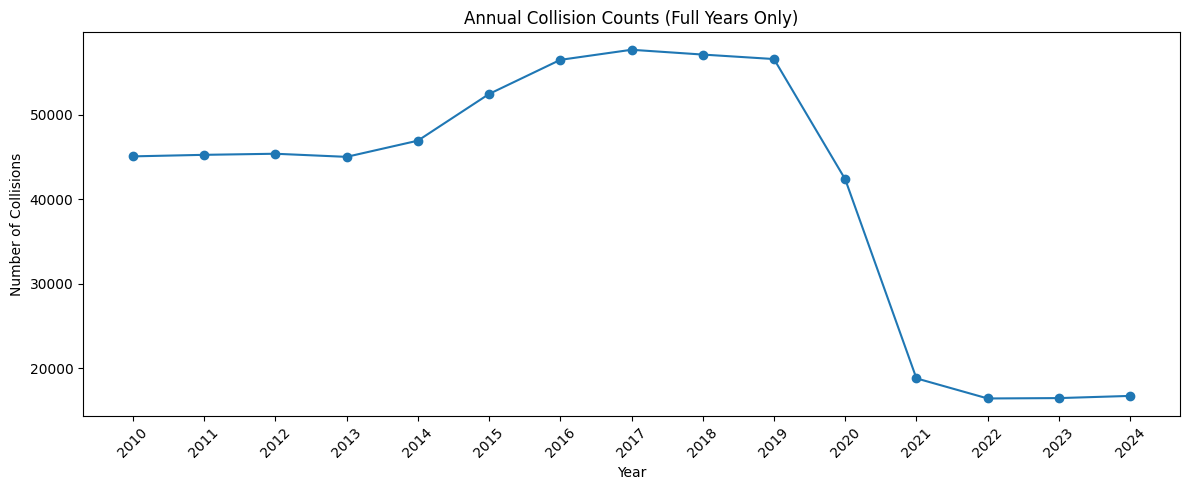


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_year_coverage_summary.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_annual_collision_trend_full_years_only.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_annual_collision_trend_full_years_only.png


In [7]:
# ============================================================
# Step 5A — Annual Trend Refinement for Partial-Year Bias
# ============================================================

# ------------------------------------------------------------
# Build yearly coverage summary
# ------------------------------------------------------------
year_coverage = (
    df_eda.groupby("occ_year", as_index=False)
    .agg(
        total_collisions=("dr_number", "count"),
        min_date=("date_occurred", "min"),
        max_date=("date_occurred", "max"),
        covered_days=("date_occurred", "nunique"),
    )
    .sort_values("occ_year")
    .reset_index(drop=True)
)

year_coverage["year_start_expected"] = pd.to_datetime(year_coverage["occ_year"].astype(str) + "-01-01")
year_coverage["year_end_expected"] = pd.to_datetime(year_coverage["occ_year"].astype(str) + "-12-31")

year_coverage["is_full_year"] = (
    (year_coverage["min_date"] == year_coverage["year_start_expected"]) &
    (year_coverage["max_date"] == year_coverage["year_end_expected"])
)

# ------------------------------------------------------------
# Full-year-only trend table
# ------------------------------------------------------------
annual_collisions_full_years = (
    year_coverage.loc[year_coverage["is_full_year"]].copy()
    .sort_values("occ_year")
    .reset_index(drop=True)
)

annual_collisions_full_years["yoy_abs_change"] = annual_collisions_full_years["total_collisions"].diff()
annual_collisions_full_years["yoy_pct_change"] = (
    annual_collisions_full_years["total_collisions"].pct_change() * 100
).round(2)

print("=" * 70)
print("Year Coverage Summary")
print("=" * 70)
display(
    year_coverage[
        [
            "occ_year", "total_collisions", "min_date", "max_date",
            "covered_days", "is_full_year"
        ]
    ]
)

print("\n" + "=" * 70)
print("Annual Trend — Full Years Only")
print("=" * 70)
display(annual_collisions_full_years[["occ_year", "total_collisions", "yoy_abs_change", "yoy_pct_change"]])

# ------------------------------------------------------------
# Plot full-year-only trend
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    annual_collisions_full_years["occ_year"],
    annual_collisions_full_years["total_collisions"],
    marker="o"
)

plt.title("Annual Collision Counts (Full Years Only)")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.xticks(annual_collisions_full_years["occ_year"], rotation=45)
plt.tight_layout()

full_year_fig_path = OUTPUT_FIGURES / "eda_annual_collision_trend_full_years_only.png"
plt.savefig(full_year_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
year_coverage_path = OUTPUT_TABLES / "eda_year_coverage_summary.csv"
annual_full_years_path = OUTPUT_TABLES / "eda_annual_collision_trend_full_years_only.csv"

year_coverage.to_csv(year_coverage_path, index=False)
annual_collisions_full_years.to_csv(annual_full_years_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(year_coverage_path)
print(annual_full_years_path)
print(full_year_fig_path)

## Annual Trend Interpretation Note

The annual trend becomes methodologically more reliable after excluding the partial year 2025.

Key observations:
- collision counts were broadly stable from 2010 to 2014
- a clear growth phase appears from 2014 to 2017
- a mild decline starts in 2018 and continues into 2019
- a major downward structural shift appears in 2020
- a much sharper decline is observed in 2021
- volumes remain comparatively low and stable from 2022 to 2024

Analytical caution:
The decline from 2020 onward should not be interpreted automatically as an improvement in traffic safety.
It may reflect a combination of real-world behavioral change, reporting variation, administrative change, or source-coverage differences.
Therefore, the trend should be described as a **recorded collision volume trend**, not as a direct safety-performance conclusion.

## Step 6 — Monthly Collision Trend Analysis

This section examines the monthly distribution of recorded collisions.

The objectives are to:
- understand how collision volume is distributed across calendar months
- identify broad seasonal patterns
- detect whether some months systematically show higher or lower recorded collision counts

This is the second layer of time analysis after the annual trend and helps reveal recurring seasonal structure in the data.

Monthly Collision Distribution


,occ_month,occ_month_name,total_collisions,pct_of_total_collisions
0,1,January,51995,8.36
1,2,February,50026,8.05
2,3,March,53486,8.60
3,4,April,49407,7.95
4,5,May,50793,8.17
5,6,June,50093,8.06
6,7,July,51731,8.32
7,8,August,53749,8.65
8,9,September,51866,8.34
9,10,October,55446,8.92


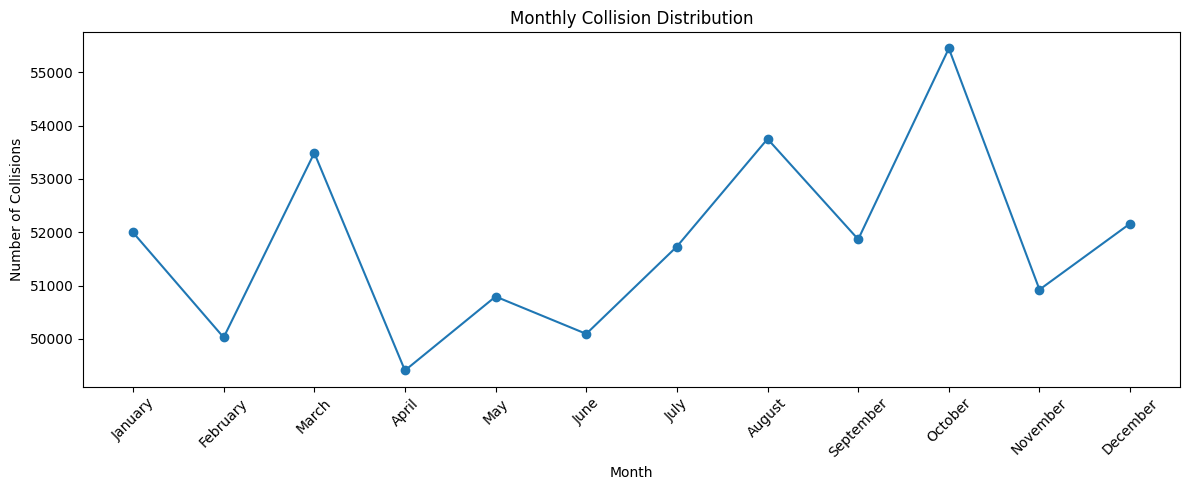


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_monthly_collision_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_monthly_collision_distribution.png


In [8]:
# ============================================================
# Step 6 — Monthly Collision Trend Analysis
# ============================================================

monthly_collisions = (
    df_eda.groupby(["occ_month", "occ_month_name"], as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

month_order = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}

monthly_collisions["month_order"] = monthly_collisions["occ_month_name"].map(month_order)
monthly_collisions = (
    monthly_collisions
    .sort_values("month_order")
    .reset_index(drop=True)
)

monthly_collisions["pct_of_total_collisions"] = (
    monthly_collisions["total_collisions"] / monthly_collisions["total_collisions"].sum() * 100
).round(2)

print("=" * 70)
print("Monthly Collision Distribution")
print("=" * 70)
display(monthly_collisions[["occ_month", "occ_month_name", "total_collisions", "pct_of_total_collisions"]])

# ------------------------------------------------------------
# Plot monthly distribution
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_collisions["occ_month_name"],
    monthly_collisions["total_collisions"],
    marker="o"
)

plt.title("Monthly Collision Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()

monthly_fig_path = OUTPUT_FIGURES / "eda_monthly_collision_distribution.png"
plt.savefig(monthly_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save output
# ------------------------------------------------------------
monthly_table_path = OUTPUT_TABLES / "eda_monthly_collision_distribution.csv"
monthly_collisions.to_csv(monthly_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(monthly_table_path)
print(monthly_fig_path)

## Step 6A — Refined Monthly Seasonality Using Full Years Only

Raw monthly totals are useful as an initial view, but they are influenced by differences in annual collision volume across years.

To improve interpretability, this step estimates monthly seasonality using:
- full years only
- average collision counts for each month across full years

This provides a cleaner view of recurring month-level seasonal structure and reduces distortion from partial years and major long-term shifts in annual volume.

Monthly Seasonality Summary — Full Years Only


,occ_month,occ_month_name,avg_collisions,median_collisions,min_collisions,max_collisions,std_collisions,seasonality_index
0,1,January,3394.13,3720.0,1314,4593,1178.54,0.987
1,2,February,3249.60,3600.0,1047,4584,1322.41,0.945
2,3,March,3551.40,3900.0,1312,5079,1391.13,1.033
3,4,April,3293.80,3701.0,1304,4730,1313.64,0.958
4,5,May,3386.20,3809.0,1369,4849,1299.98,0.985
5,6,June,3339.53,3647.0,1360,4819,1290.64,0.971
6,7,July,3448.73,3758.0,1344,4918,1326.79,1.003
7,8,August,3583.27,3951.0,1248,5006,1432.48,1.042
8,9,September,3457.73,3796.0,1307,4912,1363.91,1.005
9,10,October,3696.40,4050.0,1386,5285,1463.43,1.075


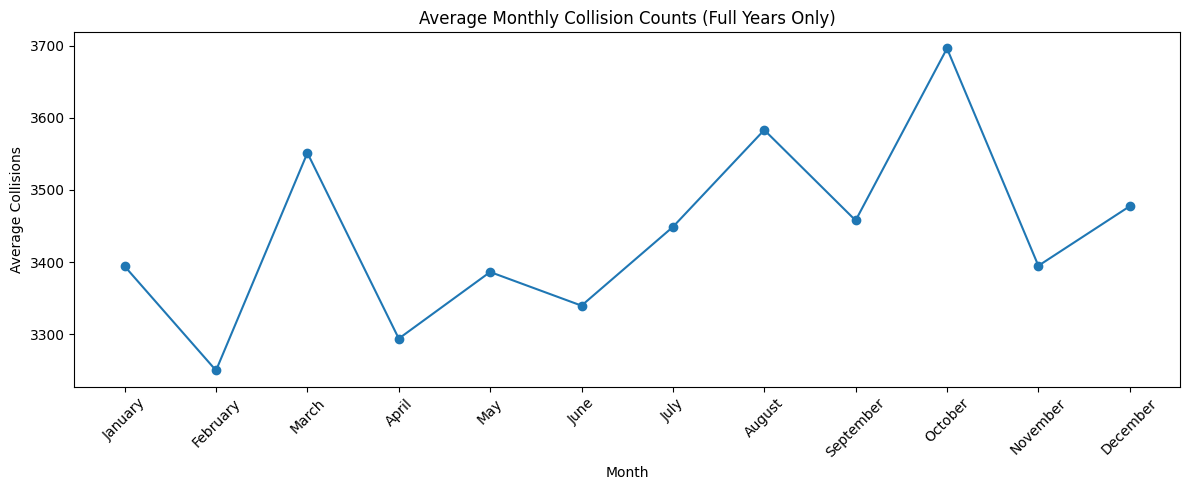


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_monthly_collisions_by_year_full_years.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_monthly_seasonality_full_years_only.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_monthly_seasonality_full_years_only.png


In [9]:
# ============================================================
# Step 6A — Refined Monthly Seasonality Using Full Years Only
# ============================================================

# ------------------------------------------------------------
# Keep only full-year records
# ------------------------------------------------------------
full_years = year_coverage.loc[year_coverage["is_full_year"], "occ_year"].tolist()

df_eda_full_years = df_eda[df_eda["occ_year"].isin(full_years)].copy()

# ------------------------------------------------------------
# Monthly counts by year, then average across years
# ------------------------------------------------------------
monthly_by_year = (
    df_eda_full_years.groupby(["occ_year", "occ_month", "occ_month_name"], as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

monthly_seasonality = (
    monthly_by_year.groupby(["occ_month", "occ_month_name"], as_index=False)
    .agg(
        avg_collisions=("total_collisions", "mean"),
        median_collisions=("total_collisions", "median"),
        min_collisions=("total_collisions", "min"),
        max_collisions=("total_collisions", "max"),
        std_collisions=("total_collisions", "std"),
    )
)

month_order = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}

monthly_seasonality["month_order"] = monthly_seasonality["occ_month_name"].map(month_order)
monthly_seasonality = monthly_seasonality.sort_values("month_order").reset_index(drop=True)

monthly_seasonality["avg_collisions"] = monthly_seasonality["avg_collisions"].round(2)
monthly_seasonality["median_collisions"] = monthly_seasonality["median_collisions"].round(2)
monthly_seasonality["std_collisions"] = monthly_seasonality["std_collisions"].round(2)

monthly_seasonality["seasonality_index"] = (
    monthly_seasonality["avg_collisions"] / monthly_seasonality["avg_collisions"].mean()
).round(3)

print("=" * 70)
print("Monthly Seasonality Summary — Full Years Only")
print("=" * 70)
display(
    monthly_seasonality[
        [
            "occ_month",
            "occ_month_name",
            "avg_collisions",
            "median_collisions",
            "min_collisions",
            "max_collisions",
            "std_collisions",
            "seasonality_index",
        ]
    ]
)

# ------------------------------------------------------------
# Plot refined monthly seasonality
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_seasonality["occ_month_name"],
    monthly_seasonality["avg_collisions"],
    marker="o"
)

plt.title("Average Monthly Collision Counts (Full Years Only)")
plt.xlabel("Month")
plt.ylabel("Average Collisions")
plt.xticks(rotation=45)
plt.tight_layout()

monthly_seasonality_fig_path = OUTPUT_FIGURES / "eda_monthly_seasonality_full_years_only.png"
plt.savefig(monthly_seasonality_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
monthly_by_year_path = OUTPUT_TABLES / "eda_monthly_collisions_by_year_full_years.csv"
monthly_seasonality_path = OUTPUT_TABLES / "eda_monthly_seasonality_full_years_only.csv"

monthly_by_year.to_csv(monthly_by_year_path, index=False)
monthly_seasonality.to_csv(monthly_seasonality_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(monthly_by_year_path)
print(monthly_seasonality_path)
print(monthly_seasonality_fig_path)

## Step 6B — Monthly Heatmap by Year

To better understand monthly seasonality, we examine monthly collision counts at the year-month level.

This step helps answer an important analytical question:

Are the apparent monthly peaks and dips recurring across many years,
or are they driven mainly by a small number of specific years?

A year-by-month heatmap is useful here because it visually combines:
- long-term trend
- seasonal month-level structure
- year-specific variation

Monthly Heatmap Pivot Table


occ_month_name,January,February,March,April,May,June,July,August,September,October,November,December
occ_year,,,,,,,,,,,,
2010,3723.0,3492.0,3900.0,3670.0,3809.0,3634.0,3758.0,3680.0,3583.0,4050.0,3725.0,4074.0
2011,3506.0,3602.0,3984.0,3657.0,3714.0,3647.0,3847.0,3930.0,3822.0,3998.0,3740.0,3833.0
2012,3720.0,3600.0,4179.0,3739.0,3764.0,3679.0,3686.0,3951.0,3796.0,4024.0,3612.0,3659.0
2013,3571.0,3362.0,3860.0,3739.0,3881.0,3579.0,3646.0,4032.0,3746.0,4127.0,3796.0,3701.0
2014,3587.0,3502.0,3880.0,3701.0,3887.0,3906.0,3839.0,4183.0,4112.0,4293.0,3882.0,4185.0
2015,4101.0,3915.0,4457.0,4217.0,4258.0,4183.0,4313.0,4705.0,4468.0,4814.0,4471.0,4586.0
2016,4178.0,4529.0,4688.0,4730.0,4625.0,4819.0,4673.0,4961.0,4837.0,4923.0,4634.0,4935.0
2017,4518.0,4312.0,5079.0,4681.0,4849.0,4762.0,4808.0,4987.0,4660.0,5285.0,4856.0,4930.0
2018,4593.0,4475.0,4927.0,4689.0,4580.0,4649.0,4918.0,5006.0,4706.0,5201.0,4780.0,4635.0


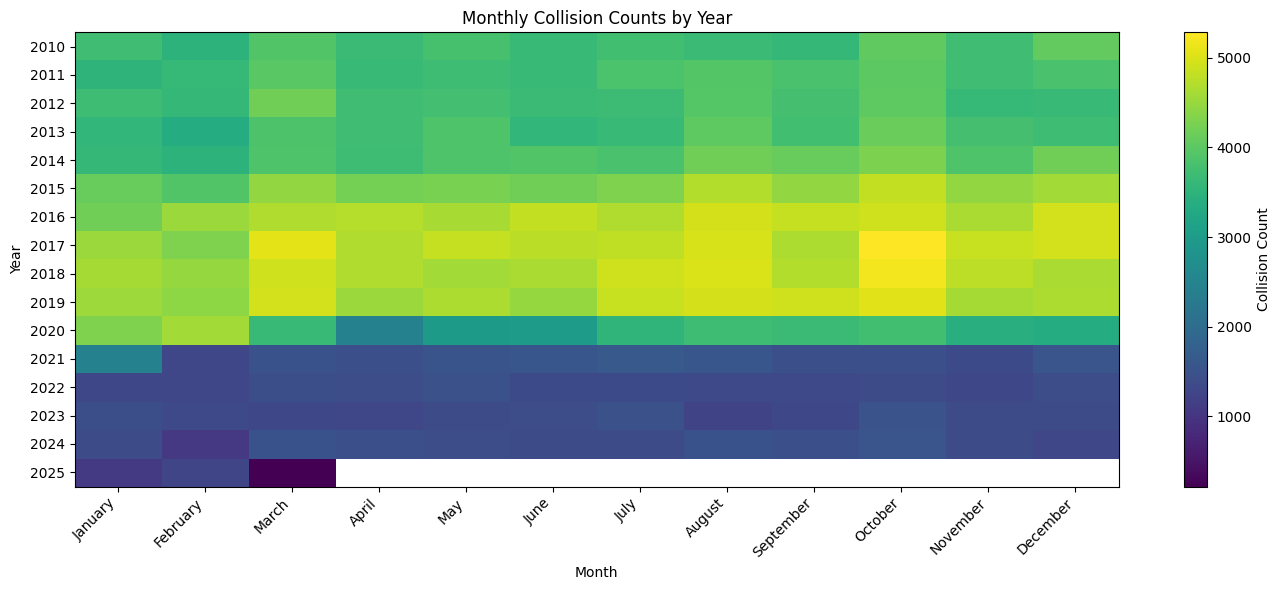


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_monthly_heatmap_by_year.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_monthly_heatmap_by_year.png


In [10]:
# ============================================================
# Step 6B — Monthly Heatmap by Year
# ============================================================

monthly_heatmap_df = (
    df_eda.groupby(["occ_year", "occ_month_name"], as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

month_order = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}

monthly_heatmap_df["month_order"] = monthly_heatmap_df["occ_month_name"].map(month_order)

monthly_heatmap_pivot = (
    monthly_heatmap_df
    .sort_values(["occ_year", "month_order"])
    .pivot(index="occ_year", columns="occ_month_name", values="total_collisions")
)

ordered_months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
monthly_heatmap_pivot = monthly_heatmap_pivot[ordered_months]

print("=" * 70)
print("Monthly Heatmap Pivot Table")
print("=" * 70)
display(monthly_heatmap_pivot)

# ------------------------------------------------------------
# Plot heatmap using matplotlib only
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(monthly_heatmap_pivot.values, aspect="auto")

ax.set_title("Monthly Collision Counts by Year")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

ax.set_xticks(range(len(monthly_heatmap_pivot.columns)))
ax.set_xticklabels(monthly_heatmap_pivot.columns, rotation=45, ha="right")

ax.set_yticks(range(len(monthly_heatmap_pivot.index)))
ax.set_yticklabels(monthly_heatmap_pivot.index)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Collision Count")

plt.tight_layout()

heatmap_fig_path = OUTPUT_FIGURES / "eda_monthly_heatmap_by_year.png"
plt.savefig(heatmap_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
heatmap_table_path = OUTPUT_TABLES / "eda_monthly_heatmap_by_year.csv"
monthly_heatmap_pivot.to_csv(heatmap_table_path)

print("\n" + "-" * 70)
print("Saved outputs:")
print(heatmap_table_path)
print(heatmap_fig_path)

## Step 7 — Weekday Collision Analysis

This section examines how recorded collisions are distributed across days of the week.

The goals are to:
- identify which weekdays carry the highest collision volume
- compare weekday patterns across the full dataset
- support later interpretation of commuting, workweek, and weekend effects

This step extends the temporal analysis from annual and monthly structure into weekly behavioral rhythm.

Weekday Collision Distribution


,occ_weekday_name,total_collisions,pct_of_total_collisions
0,Monday,85683,13.78
1,Tuesday,87198,14.03
2,Wednesday,88075,14.17
3,Thursday,89352,14.37
4,Friday,98171,15.79
5,Saturday,90556,14.57
6,Sunday,82642,13.29


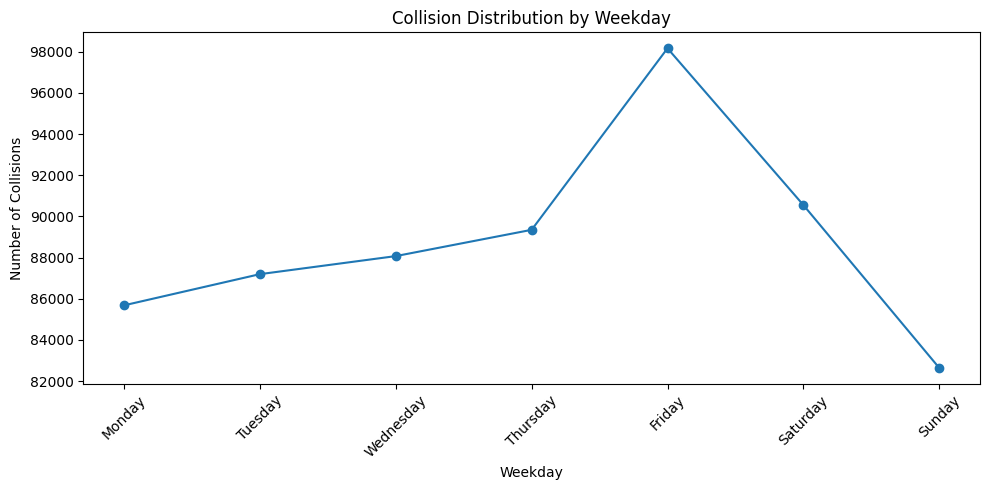


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_weekday_collision_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_weekday_collision_distribution.png


In [11]:
# ============================================================
# Step 7 — Weekday Collision Analysis
# ============================================================

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_collisions = (
    df_eda.groupby("occ_weekday_name", as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

weekday_collisions["weekday_order"] = pd.Categorical(
    weekday_collisions["occ_weekday_name"],
    categories=weekday_order,
    ordered=True
)

weekday_collisions = (
    weekday_collisions
    .sort_values("weekday_order")
    .reset_index(drop=True)
)

weekday_collisions["pct_of_total_collisions"] = (
    weekday_collisions["total_collisions"] / weekday_collisions["total_collisions"].sum() * 100
).round(2)

print("=" * 70)
print("Weekday Collision Distribution")
print("=" * 70)
display(weekday_collisions[["occ_weekday_name", "total_collisions", "pct_of_total_collisions"]])

# ------------------------------------------------------------
# Plot weekday distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(
    weekday_collisions["occ_weekday_name"],
    weekday_collisions["total_collisions"],
    marker="o"
)

plt.title("Collision Distribution by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()

weekday_fig_path = OUTPUT_FIGURES / "eda_weekday_collision_distribution.png"
plt.savefig(weekday_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
weekday_table_path = OUTPUT_TABLES / "eda_weekday_collision_distribution.csv"
weekday_collisions.to_csv(weekday_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(weekday_table_path)
print(weekday_fig_path)

## Step 8 — Hour-of-Day Collision Analysis

This section examines how recorded collisions are distributed across the 24-hour day.

The objectives are to:
- identify peak collision hours
- detect broad daily rhythm in recorded collisions
- support interpretation of commuting effects, nighttime risk, and operational activity patterns

This step is important because hourly structure often reveals behavioral concentration that is not visible from weekday analysis alone.

Hourly Collision Distribution


,occ_hour,total_collisions,pct_of_total_collisions
0,0,16596,2.67
1,1,15222,2.45
2,2,15494,2.49
3,3,10108,1.63
4,4,7475,1.20
5,5,8540,1.37
6,6,13231,2.13
7,7,25880,4.16
8,8,29230,4.70
9,9,25721,4.14


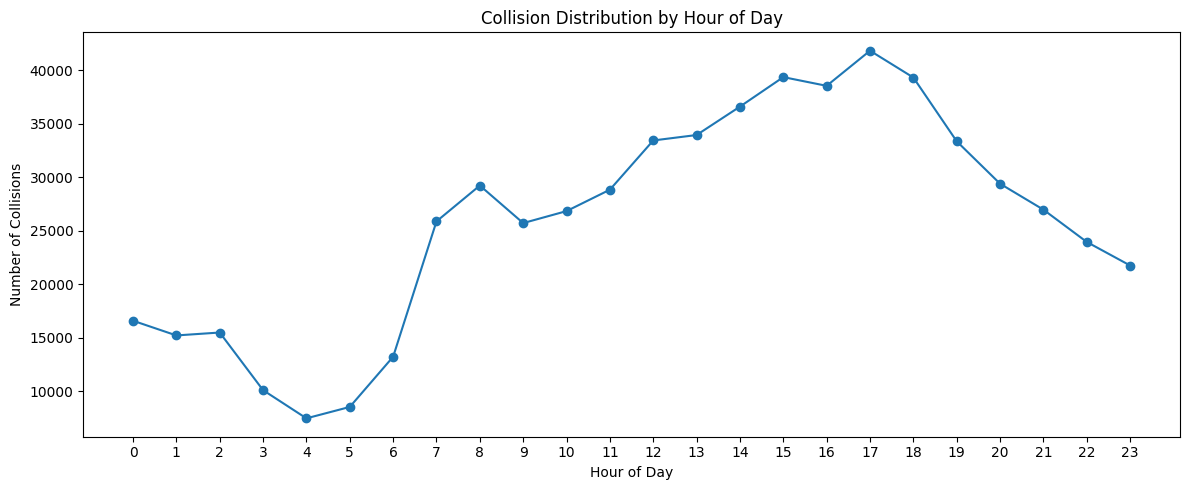


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_hourly_collision_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_hourly_collision_distribution.png


In [12]:
# ============================================================
# Step 8 — Hour-of-Day Collision Analysis
# ============================================================

hourly_collisions = (
    df_eda.groupby("occ_hour", as_index=False)
    .agg(total_collisions=("dr_number", "count"))
    .sort_values("occ_hour")
    .reset_index(drop=True)
)

hourly_collisions["pct_of_total_collisions"] = (
    hourly_collisions["total_collisions"] / hourly_collisions["total_collisions"].sum() * 100
).round(2)

print("=" * 70)
print("Hourly Collision Distribution")
print("=" * 70)
display(hourly_collisions)

# ------------------------------------------------------------
# Plot hourly distribution
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    hourly_collisions["occ_hour"],
    hourly_collisions["total_collisions"],
    marker="o"
)

plt.title("Collision Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.xticks(range(24))
plt.tight_layout()

hourly_fig_path = OUTPUT_FIGURES / "eda_hourly_collision_distribution.png"
plt.savefig(hourly_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
hourly_table_path = OUTPUT_TABLES / "eda_hourly_collision_distribution.csv"
hourly_collisions.to_csv(hourly_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(hourly_table_path)
print(hourly_fig_path)

## Step 8A — Time-of-Day Band Analysis

To make the hourly pattern easier to interpret, this step groups the 24-hour day into broader time-of-day bands.

This helps translate the raw hourly curve into business-readable categories such as:
- overnight
- early morning
- morning peak
- midday
- afternoon / evening peak
- late evening

This banded view is especially useful for reporting and dashboard communication.

Time-of-Day Band Summary


,time_band,total_collisions,pct_of_total_collisions
0,Overnight (00:00-05:59),73435,11.81
1,Early Morning (06:00-08:59),68341,10.99
2,Late Morning (09:00-11:59),81404,13.09
3,Midday (12:00-14:59),103995,16.73
4,Afternoon / Evening Peak (15:00-18:59),159057,25.59
5,Late Evening (19:00-23:59),135445,21.79


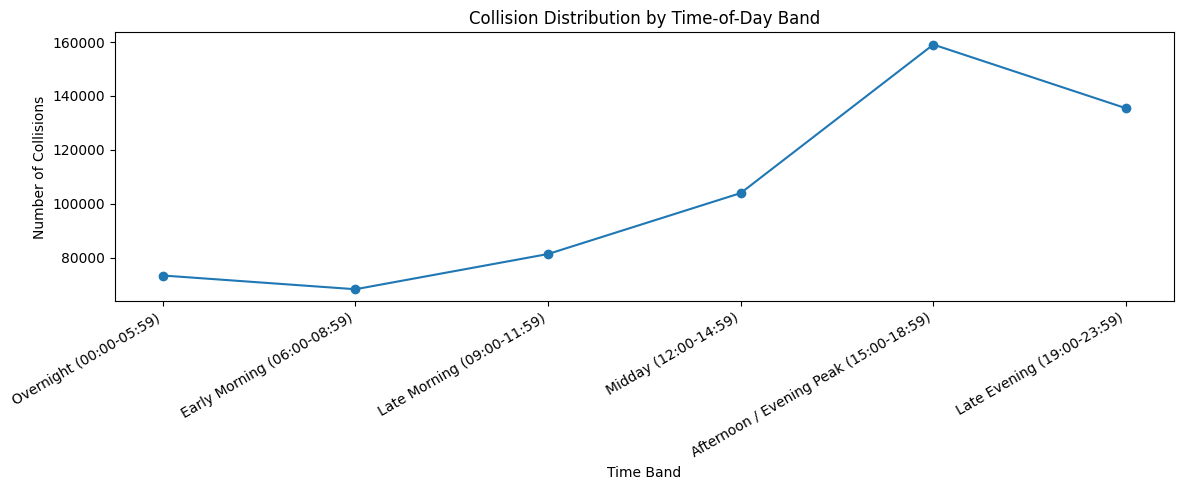


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_time_band_collision_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_time_band_collision_distribution.png


In [13]:
# ============================================================
# Step 8A — Time-of-Day Band Analysis
# ============================================================

df_eda_timebands = df_eda.copy()

def assign_time_band(hour):
    if pd.isna(hour):
        return np.nan
    hour = int(hour)
    if 0 <= hour <= 5:
        return "Overnight (00:00-05:59)"
    elif 6 <= hour <= 8:
        return "Early Morning (06:00-08:59)"
    elif 9 <= hour <= 11:
        return "Late Morning (09:00-11:59)"
    elif 12 <= hour <= 14:
        return "Midday (12:00-14:59)"
    elif 15 <= hour <= 18:
        return "Afternoon / Evening Peak (15:00-18:59)"
    elif 19 <= hour <= 23:
        return "Late Evening (19:00-23:59)"
    return "Unknown"

time_band_order = [
    "Overnight (00:00-05:59)",
    "Early Morning (06:00-08:59)",
    "Late Morning (09:00-11:59)",
    "Midday (12:00-14:59)",
    "Afternoon / Evening Peak (15:00-18:59)",
    "Late Evening (19:00-23:59)",
]

df_eda_timebands["time_band"] = df_eda_timebands["occ_hour"].apply(assign_time_band)

time_band_summary = (
    df_eda_timebands.groupby("time_band", as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

time_band_summary["time_band"] = pd.Categorical(
    time_band_summary["time_band"],
    categories=time_band_order,
    ordered=True
)

time_band_summary = (
    time_band_summary.sort_values("time_band").reset_index(drop=True)
)

time_band_summary["pct_of_total_collisions"] = (
    time_band_summary["total_collisions"] / time_band_summary["total_collisions"].sum() * 100
).round(2)

print("=" * 70)
print("Time-of-Day Band Summary")
print("=" * 70)
display(time_band_summary)

# ------------------------------------------------------------
# Plot band summary
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    time_band_summary["time_band"].astype(str),
    time_band_summary["total_collisions"],
    marker="o"
)

plt.title("Collision Distribution by Time-of-Day Band")
plt.xlabel("Time Band")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

time_band_fig_path = OUTPUT_FIGURES / "eda_time_band_collision_distribution.png"
plt.savefig(time_band_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
time_band_table_path = OUTPUT_TABLES / "eda_time_band_collision_distribution.csv"
time_band_summary.to_csv(time_band_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(time_band_table_path)
print(time_band_fig_path)

## Step 8B — Weekday × Hour Heatmap

This section combines weekday structure with hour-of-day structure.

The objective is to identify:
- whether peak hours differ by weekday
- whether Friday and weekend patterns have distinct hourly concentration
- how daily rhythm changes across the week

This is one of the most informative temporal views in the notebook because it connects weekly behavior with within-day intensity.

Weekday × Hour Pivot Table


occ_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
occ_weekday_name,,,,,,,,,,,,,,,,,,,,,,,,
Monday,2164,1806,1649,1120,905,1178,2068,4213,4707,3881,3887,4174,4869,4751,5244,5741,5574,6138,5546,4241,3629,3176,2700,2322
Tuesday,1633,1292,1117,755,671,1092,2024,4767,5201,4336,4099,4321,4898,5134,5363,5813,5722,6316,5810,4653,3679,3314,2790,2398
Wednesday,1669,1419,1253,862,720,1061,2096,4543,5196,4183,4115,4246,4987,4763,5308,5739,5773,6384,5987,4882,3880,3473,3006,2530
Thursday,1800,1535,1394,899,739,1050,2100,4610,5019,4092,4014,4222,4853,4808,5358,5945,5847,6456,5985,4795,4000,3696,3235,2900
Friday,2058,1852,1861,1161,897,1263,2030,4215,4779,4052,4013,4374,5043,5351,5710,6624,6462,6864,6467,5533,4833,4427,4204,4098
Saturday,3269,3341,3882,2378,1685,1449,1524,1986,2435,2908,3600,4058,4872,4874,5074,5029,4829,4993,5062,4902,4777,4661,4473,4495
Sunday,4003,3977,4338,2933,1858,1447,1389,1546,1893,2269,3113,3447,3919,4269,4547,4470,4339,4677,4465,4356,4600,4226,3548,3013


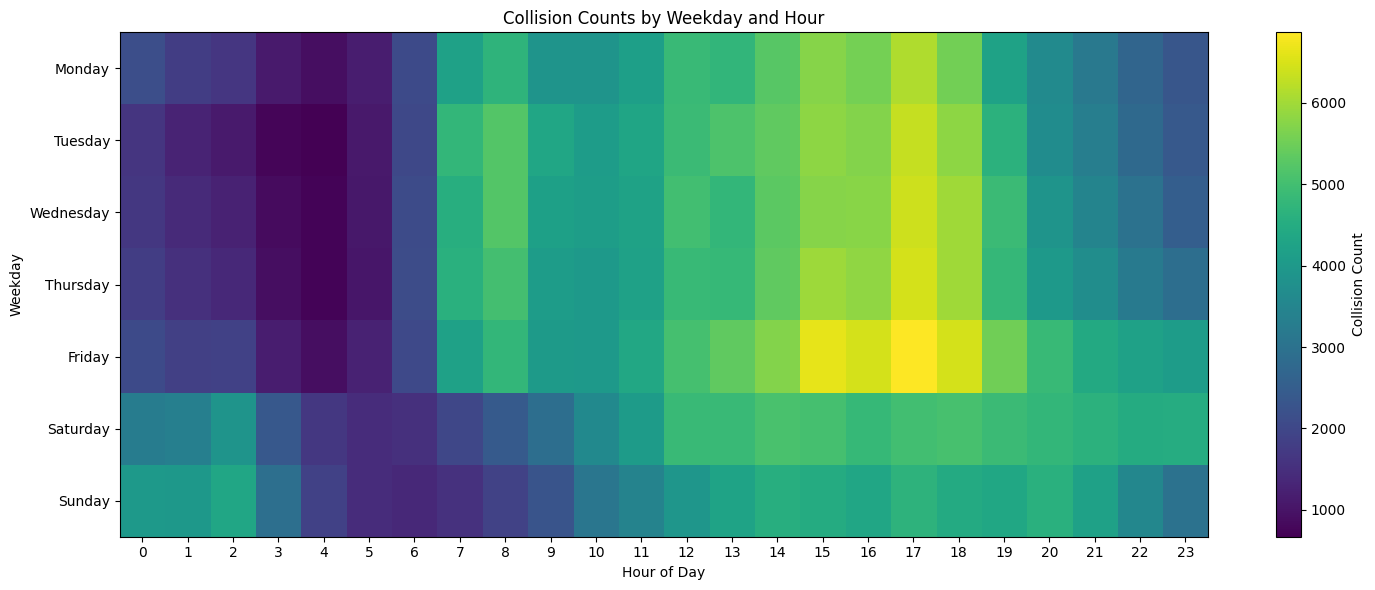


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_weekday_hour_heatmap.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_weekday_hour_heatmap.png


In [14]:
# ============================================================
# Step 8B — Weekday × Hour Heatmap
# ============================================================

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_hour_df = (
    df_eda.groupby(["occ_weekday_name", "occ_hour"], as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

weekday_hour_df["occ_weekday_name"] = pd.Categorical(
    weekday_hour_df["occ_weekday_name"],
    categories=weekday_order,
    ordered=True
)

weekday_hour_pivot = (
    weekday_hour_df
    .sort_values(["occ_weekday_name", "occ_hour"])
    .pivot(index="occ_weekday_name", columns="occ_hour", values="total_collisions")
)

print("=" * 70)
print("Weekday × Hour Pivot Table")
print("=" * 70)
display(weekday_hour_pivot)

# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(weekday_hour_pivot.values, aspect="auto")

ax.set_title("Collision Counts by Weekday and Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Weekday")

ax.set_xticks(range(len(weekday_hour_pivot.columns)))
ax.set_xticklabels(weekday_hour_pivot.columns)

ax.set_yticks(range(len(weekday_hour_pivot.index)))
ax.set_yticklabels(weekday_hour_pivot.index.astype(str))

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Collision Count")

plt.tight_layout()

weekday_hour_fig_path = OUTPUT_FIGURES / "eda_weekday_hour_heatmap.png"
plt.savefig(weekday_hour_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
weekday_hour_table_path = OUTPUT_TABLES / "eda_weekday_hour_heatmap.csv"
weekday_hour_pivot.to_csv(weekday_hour_table_path)

print("\n" + "-" * 70)
print("Saved outputs:")
print(weekday_hour_table_path)
print(weekday_hour_fig_path)

## Step 9 — Area-Level Collision Analysis

This section shifts the analysis from time to geography.

The objectives are to:
- identify which LAPD areas record the highest collision volume
- compare area concentration across the dataset
- prepare the analytical foundation for later hotspot and location-based interpretation

This is the first spatial layer in the notebook and helps reveal where collision burden is most concentrated geographically.

Area-Level Collision Distribution


,area_id,area_name,total_collisions,pct_of_total_collisions,rank
0,12,77th Street,41780,6.72,1
1,3,Southwest,36394,5.85,2
2,7,Wilshire,34640,5.57,3
3,20,Olympic,32445,5.22,4
4,13,Newton,32399,5.21,5
5,15,N Hollywood,32348,5.20,6
6,8,West LA,32208,5.18,7
7,14,Pacific,31867,5.13,8
8,9,Van Nuys,30621,4.93,9
9,17,Devonshire,30289,4.87,10


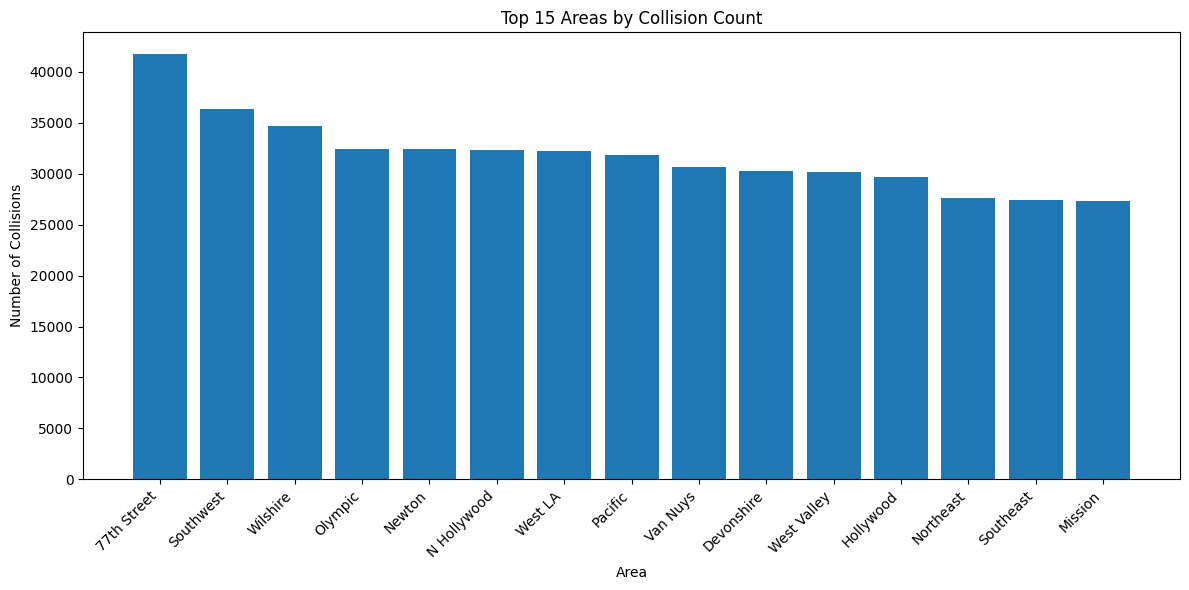


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_area_collision_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_top_areas_collision_distribution.png


In [15]:
# ============================================================
# Step 9 — Area-Level Collision Analysis
# ============================================================

area_collisions = (
    df_eda.groupby(["area_id", "area_name"], as_index=False)
    .agg(total_collisions=("dr_number", "count"))
    .sort_values("total_collisions", ascending=False)
    .reset_index(drop=True)
)

area_collisions["pct_of_total_collisions"] = (
    area_collisions["total_collisions"] / area_collisions["total_collisions"].sum() * 100
).round(2)

area_collisions["rank"] = area_collisions["total_collisions"].rank(
    method="dense", ascending=False
).astype(int)

print("=" * 70)
print("Area-Level Collision Distribution")
print("=" * 70)
display(area_collisions)

# ------------------------------------------------------------
# Plot top areas
# ------------------------------------------------------------
top_n = 15
area_top = area_collisions.head(top_n).copy()

plt.figure(figsize=(12, 6))
plt.bar(area_top["area_name"], area_top["total_collisions"])

plt.title(f"Top {top_n} Areas by Collision Count")
plt.xlabel("Area")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

area_fig_path = OUTPUT_FIGURES / "eda_top_areas_collision_distribution.png"
plt.savefig(area_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
area_table_path = OUTPUT_TABLES / "eda_area_collision_distribution.csv"
area_collisions.to_csv(area_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(area_table_path)
print(area_fig_path)

## Step 9A — Reporting District Analysis

Area-level analysis provides a broad geographic view, but reporting districts offer a more granular spatial layer.

The objectives of this step are to:
- identify the reporting districts with the highest recorded collision volume
- detect local spatial concentration within larger LAPD areas
- prepare a more detailed hotspot-oriented geographic perspective

This step is important because collision concentration is often more visible at sub-area level than at broad area level.

Reporting District Collision Distribution
Using reporting district column: reporting_district


,reporting_district,total_collisions,pct_of_total_collisions,rank
0,645,2725,0.44,1
1,1494,2573,0.41,2
2,111,2501,0.40,3
3,1309,2478,0.40,4
4,646,2420,0.39,5
5,666,2201,0.35,6
6,1822,1893,0.30,7
7,1249,1785,0.29,8
8,1764,1759,0.28,9
9,1802,1697,0.27,10


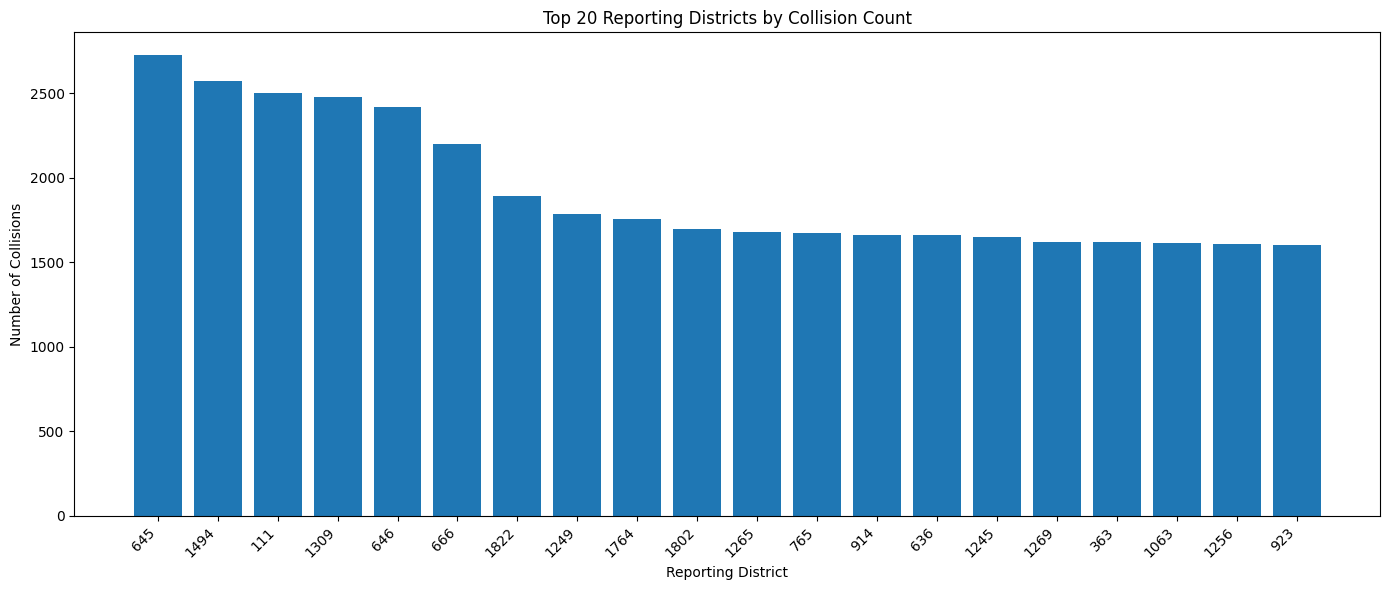


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_reporting_district_collision_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_top_reporting_districts_collision_distribution.png


In [16]:
# ============================================================
# Step 9A — Reporting District Analysis
# ============================================================

# Detect reporting district column safely
possible_rd_cols = [
    "reporting_district",
    "reporting_district_no",
    "rpt_dist_no",
    "rpt_dist_no_clean",
    "rpt_dist_no_std",
]

rd_col = next((c for c in possible_rd_cols if c in df_eda.columns), None)

if rd_col is None:
    print("Available columns:")
    print(df_eda.columns.tolist())
    raise ValueError("No reporting district column found in df_eda.")

reporting_district_collisions = (
    df_eda.groupby([rd_col], as_index=False)
    .agg(total_collisions=("dr_number", "count"))
    .sort_values("total_collisions", ascending=False)
    .reset_index(drop=True)
)

reporting_district_collisions["pct_of_total_collisions"] = (
    reporting_district_collisions["total_collisions"] /
    reporting_district_collisions["total_collisions"].sum() * 100
).round(2)

reporting_district_collisions["rank"] = reporting_district_collisions["total_collisions"].rank(
    method="dense", ascending=False
).astype(int)

print("=" * 70)
print("Reporting District Collision Distribution")
print("=" * 70)
print(f"Using reporting district column: {rd_col}")
display(reporting_district_collisions.head(25))

# ------------------------------------------------------------
# Plot top reporting districts
# ------------------------------------------------------------
top_n = 20
rd_top = reporting_district_collisions.head(top_n).copy()

plt.figure(figsize=(14, 6))
plt.bar(rd_top[rd_col].astype(str), rd_top["total_collisions"])

plt.title(f"Top {top_n} Reporting Districts by Collision Count")
plt.xlabel("Reporting District")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

rd_fig_path = OUTPUT_FIGURES / "eda_top_reporting_districts_collision_distribution.png"
plt.savefig(rd_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
rd_table_path = OUTPUT_TABLES / "eda_reporting_district_collision_distribution.csv"
reporting_district_collisions.to_csv(rd_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(rd_table_path)
print(rd_fig_path)

## Step 10 — Premise-Level Collision Analysis

This section examines the types of premises associated with recorded collisions.

The objectives are to:
- identify the most common premise types in the dataset
- understand the contextual environments where collisions are recorded
- support later interpretation of roadway, intersection, and built-environment patterns

This step adds an important situational layer to the EDA by showing where collisions are most frequently associated at the premise-description level.

Premise-Level Collision Distribution


,premise_code,premise_description,total_collisions,pct_of_total_collisions,rank
0,101.0,STREET,591306,95.26,1
1,108.0,PARKING LOT,19487,3.14,2
2,102.0,SIDEWALK,4183,0.67,3
3,103.0,ALLEY,1208,0.19,4
4,104.0,DRIVEWAY,1127,0.18,5
5,110.0,FREEWAY,620,0.10,6
6,501.0,SINGLE FAMILY DWELLING,378,0.06,7
7,301.0,GAS STATION,367,0.06,8
8,212.0,TRANSPORTATION FACILITY (AIRPORT),221,0.04,9
9,710.0,OTHER PREMISE,206,0.03,10


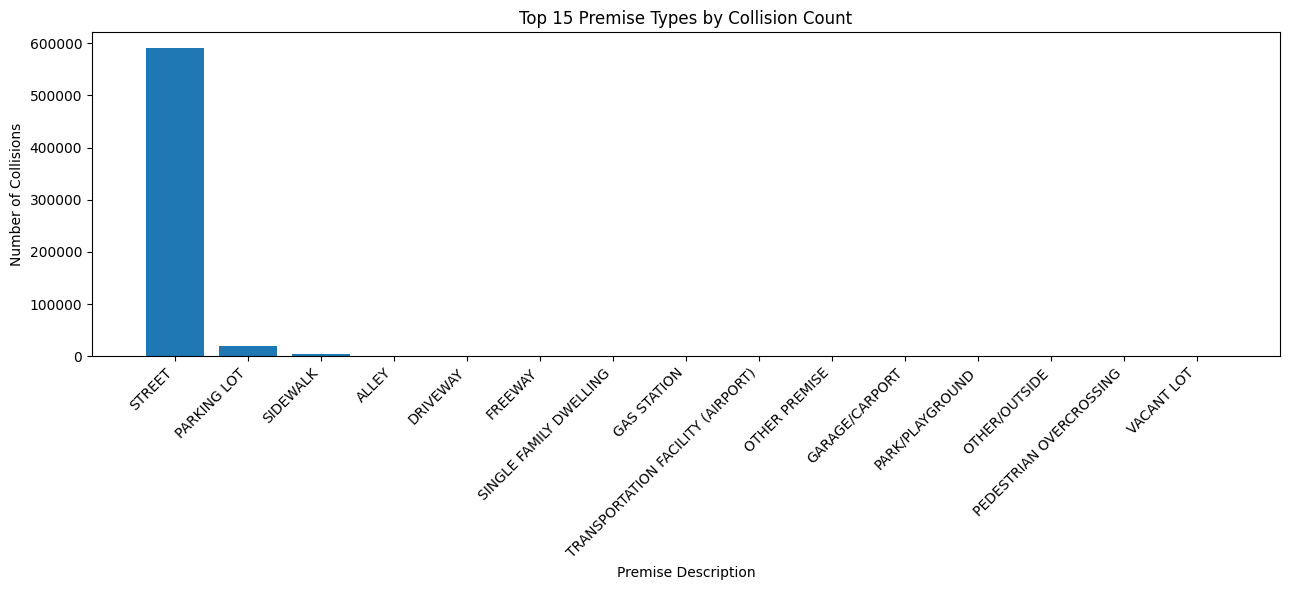


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_premise_collision_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_top_premise_collision_distribution.png


In [17]:
# ============================================================
# Step 10 — Premise-Level Collision Analysis
# ============================================================

premise_collisions = (
    df_eda.groupby(["premise_code", "premise_description"], as_index=False)
    .agg(total_collisions=("dr_number", "count"))
    .sort_values("total_collisions", ascending=False)
    .reset_index(drop=True)
)

premise_collisions["pct_of_total_collisions"] = (
    premise_collisions["total_collisions"] / premise_collisions["total_collisions"].sum() * 100
).round(2)

premise_collisions["rank"] = premise_collisions["total_collisions"].rank(
    method="dense", ascending=False
).astype(int)

print("=" * 70)
print("Premise-Level Collision Distribution")
print("=" * 70)
display(premise_collisions.head(25))

# ------------------------------------------------------------
# Plot top premise descriptions
# ------------------------------------------------------------
top_n = 15
premise_top = premise_collisions.head(top_n).copy()

plt.figure(figsize=(13, 6))
plt.bar(premise_top["premise_description"].astype(str), premise_top["total_collisions"])

plt.title(f"Top {top_n} Premise Types by Collision Count")
plt.xlabel("Premise Description")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

premise_fig_path = OUTPUT_FIGURES / "eda_top_premise_collision_distribution.png"
plt.savefig(premise_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
premise_table_path = OUTPUT_TABLES / "eda_premise_collision_distribution.csv"
premise_collisions.to_csv(premise_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(premise_table_path)
print(premise_fig_path)

## Step 10A — Premise Analysis Excluding STREET

The initial premise analysis shows that `STREET` dominates the dataset and accounts for the overwhelming majority of collision records.

While this is analytically meaningful, it makes the remaining premise structure difficult to inspect visually.

To better understand the non-street contextual environments associated with collisions, this step temporarily excludes `STREET` and re-examines the remaining premise distribution.

Premise Distribution Excluding STREET


,premise_code,premise_description,total_collisions,pct_of_total_collisions,rank,pct_of_non_street
0,108.0,PARKING LOT,19487,3.14,2,66.26
1,102.0,SIDEWALK,4183,0.67,3,14.22
2,103.0,ALLEY,1208,0.19,4,4.11
3,104.0,DRIVEWAY,1127,0.18,5,3.83
4,110.0,FREEWAY,620,0.10,6,2.11
5,501.0,SINGLE FAMILY DWELLING,378,0.06,7,1.29
6,301.0,GAS STATION,367,0.06,8,1.25
7,212.0,TRANSPORTATION FACILITY (AIRPORT),221,0.04,9,0.75
8,710.0,OTHER PREMISE,206,0.03,10,0.70
9,707.0,GARAGE/CARPORT,173,0.03,11,0.59


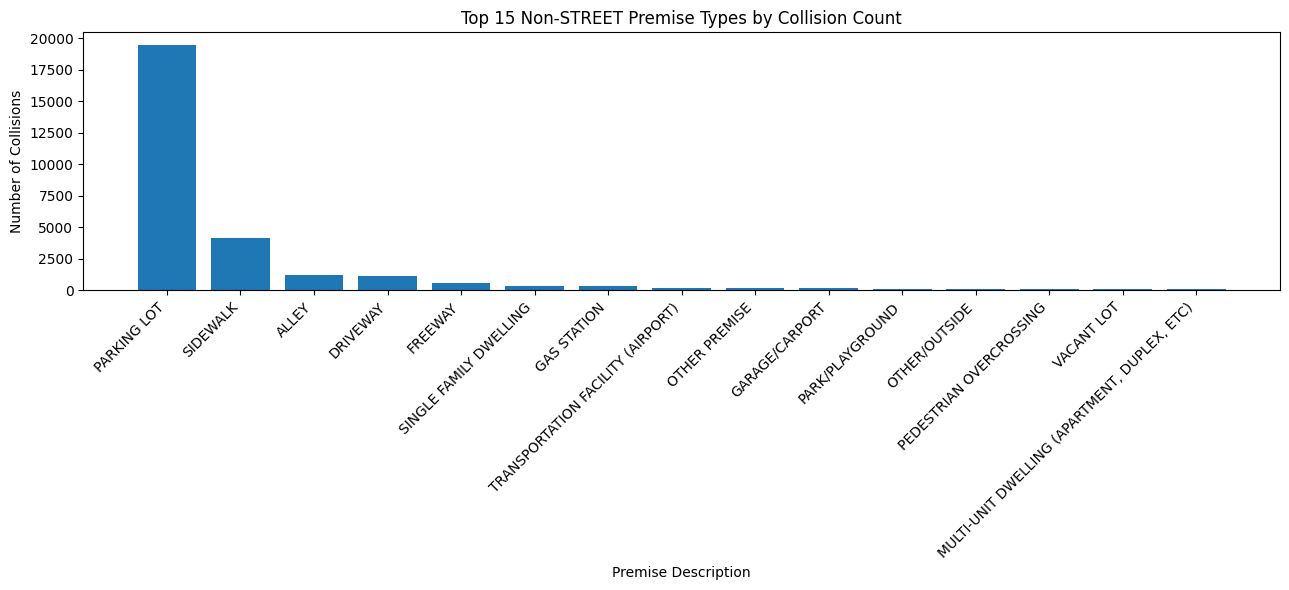


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_premise_collision_distribution_excluding_street.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_top_non_street_premise_collision_distribution.png


In [18]:
# ============================================================
# Step 10A — Premise Analysis Excluding STREET
# ============================================================

premise_non_street = (
    premise_collisions.loc[
        premise_collisions["premise_description"].astype(str).str.upper() != "STREET"
    ]
    .copy()
    .reset_index(drop=True)
)

premise_non_street["pct_of_non_street"] = (
    premise_non_street["total_collisions"] / premise_non_street["total_collisions"].sum() * 100
).round(2)

print("=" * 70)
print("Premise Distribution Excluding STREET")
print("=" * 70)
display(premise_non_street.head(25))

# ------------------------------------------------------------
# Plot top non-street premise descriptions
# ------------------------------------------------------------
top_n = 15
premise_non_street_top = premise_non_street.head(top_n).copy()

plt.figure(figsize=(13, 6))
plt.bar(
    premise_non_street_top["premise_description"].astype(str),
    premise_non_street_top["total_collisions"]
)

plt.title(f"Top {top_n} Non-STREET Premise Types by Collision Count")
plt.xlabel("Premise Description")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

premise_non_street_fig_path = OUTPUT_FIGURES / "eda_top_non_street_premise_collision_distribution.png"
plt.savefig(premise_non_street_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
premise_non_street_table_path = OUTPUT_TABLES / "eda_premise_collision_distribution_excluding_street.csv"
premise_non_street.to_csv(premise_non_street_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(premise_non_street_table_path)
print(premise_non_street_fig_path)

## Premise Interpretation Note

Premise analysis shows a highly dominant contextual pattern:

- `STREET` accounts for the overwhelming majority of recorded collisions
- after excluding `STREET`, `PARKING LOT` becomes the leading non-street premise type by a wide margin
- `SIDEWALK`, `ALLEY`, and `DRIVEWAY` appear as secondary non-street contexts, but with much smaller shares

Analytical implication:
The collision dataset is overwhelmingly road-environment driven, which is fully consistent with the traffic-collision nature of the source system.
Therefore, premise analysis is useful mainly for distinguishing the dominant street-based pattern from smaller but meaningful non-street contexts.

## Step 11 — Victim Age Analysis

This section begins the victim-profile analysis by examining victim age.

The objectives are to:
- understand the age distribution of recorded victims
- detect concentration in specific age ranges
- prepare the foundation for later grouped demographic analysis

Because victim age has some missing values, the analysis will be based on valid non-null ages only.

Victim Age Summary


,metric,value
0,total_rows_in_df_eda,621677.00
1,rows_with_non_null_age,533483.00
2,rows_with_valid_age_0_120,533483.00
3,age_missing_count,88194.00
4,age_missing_pct,14.19
5,age_min,10.00
6,age_max,99.00
7,age_mean,41.40
8,age_median,39.00



Victim Age Distribution


,victim_age,total_collisions
0,10.0,122
1,11.0,107
2,12.0,144
3,13.0,148
4,14.0,194
5,15.0,231
6,16.0,444
7,17.0,713
8,18.0,4170
9,19.0,5062


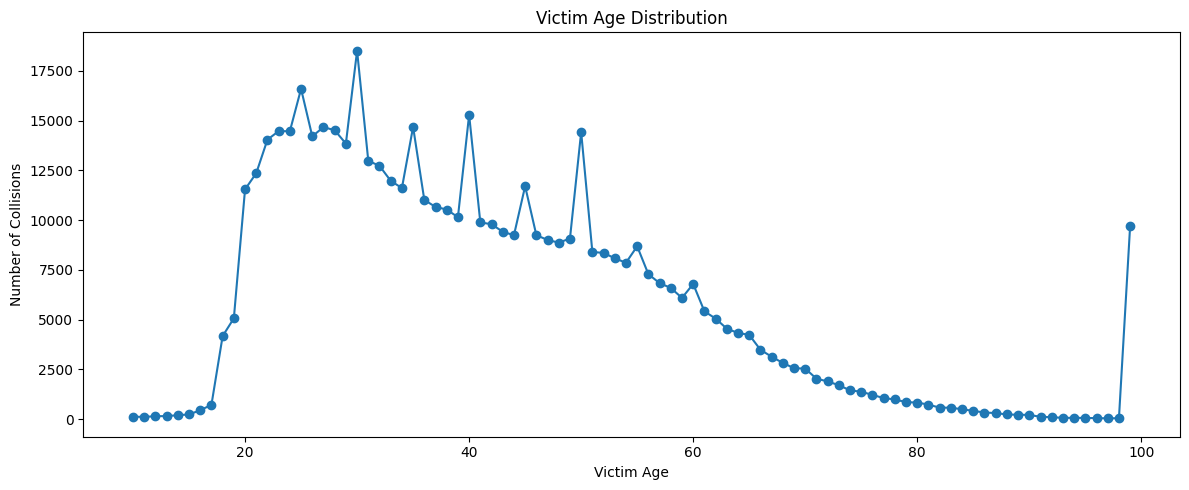


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_victim_age_summary.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_victim_age_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_victim_age_distribution.png


In [19]:
# ============================================================
# Step 11 — Victim Age Analysis
# ============================================================

df_age = df_eda.copy()

# keep valid non-null ages only
df_age_valid = df_age[df_age["victim_age"].notna()].copy()

# optional guard for non-positive or unrealistic values
df_age_valid = df_age_valid[
    (df_age_valid["victim_age"] >= 0) &
    (df_age_valid["victim_age"] <= 120)
].copy()

age_summary = pd.DataFrame({
    "metric": [
        "total_rows_in_df_eda",
        "rows_with_non_null_age",
        "rows_with_valid_age_0_120",
        "age_missing_count",
        "age_missing_pct",
        "age_min",
        "age_max",
        "age_mean",
        "age_median",
    ],
    "value": [
        len(df_eda),
        df_eda["victim_age"].notna().sum(),
        len(df_age_valid),
        df_eda["victim_age"].isna().sum(),
        round(df_eda["victim_age"].isna().mean() * 100, 2),
        df_age_valid["victim_age"].min() if len(df_age_valid) > 0 else np.nan,
        df_age_valid["victim_age"].max() if len(df_age_valid) > 0 else np.nan,
        round(df_age_valid["victim_age"].mean(), 2) if len(df_age_valid) > 0 else np.nan,
        round(df_age_valid["victim_age"].median(), 2) if len(df_age_valid) > 0 else np.nan,
    ]
})

print("=" * 70)
print("Victim Age Summary")
print("=" * 70)
display(age_summary)

# frequency by exact age
age_distribution = (
    df_age_valid.groupby("victim_age", as_index=False)
    .agg(total_collisions=("dr_number", "count"))
    .sort_values("victim_age")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Victim Age Distribution")
print("=" * 70)
display(age_distribution.head(20))

# plot
plt.figure(figsize=(12, 5))
plt.plot(
    age_distribution["victim_age"],
    age_distribution["total_collisions"],
    marker="o"
)

plt.title("Victim Age Distribution")
plt.xlabel("Victim Age")
plt.ylabel("Number of Collisions")
plt.tight_layout()

age_fig_path = OUTPUT_FIGURES / "eda_victim_age_distribution.png"
plt.savefig(age_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# save outputs
age_summary_path = OUTPUT_TABLES / "eda_victim_age_summary.csv"
age_distribution_path = OUTPUT_TABLES / "eda_victim_age_distribution.csv"

age_summary.to_csv(age_summary_path, index=False)
age_distribution.to_csv(age_distribution_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(age_summary_path)
print(age_distribution_path)
print(age_fig_path)

## Step 11A — Victim Sex Analysis

This section examines the distribution of recorded victims by sex.

The objectives are to:
- understand the sex composition of recorded victims
- quantify the relative share of each category
- document the amount of missing victim-sex information

This step complements the age analysis and helps build the demographic profile of the collision dataset.

Victim Sex Distribution


,victim_sex_label,total_collisions,pct_of_total_collisions
0,M,366612,58.97
1,F,226576,36.45
2,X,17594,2.83
3,Missing,10895,1.75


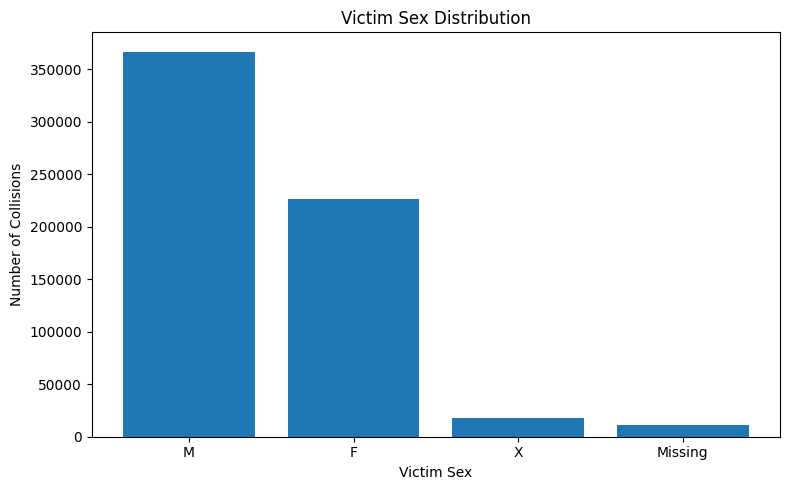


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_victim_sex_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_victim_sex_distribution.png


In [20]:
# ============================================================
# Step 11A — Victim Sex Analysis
# ============================================================

df_sex = df_eda.copy()

victim_sex_summary = (
    df_sex.groupby("victim_sex", dropna=False, as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

# convert missing to readable label
victim_sex_summary["victim_sex_label"] = victim_sex_summary["victim_sex"].astype(str)
victim_sex_summary.loc[
    victim_sex_summary["victim_sex"].isna(),
    "victim_sex_label"
] = "Missing"

victim_sex_summary["pct_of_total_collisions"] = (
    victim_sex_summary["total_collisions"] / victim_sex_summary["total_collisions"].sum() * 100
).round(2)

# optional ordered display
sex_order = ["M", "F", "X", "Missing"]
victim_sex_summary["sex_order"] = pd.Categorical(
    victim_sex_summary["victim_sex_label"],
    categories=sex_order,
    ordered=True
)

victim_sex_summary = (
    victim_sex_summary
    .sort_values(["sex_order", "victim_sex_label"])
    .reset_index(drop=True)
)

print("=" * 70)
print("Victim Sex Distribution")
print("=" * 70)
display(victim_sex_summary[["victim_sex_label", "total_collisions", "pct_of_total_collisions"]])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(
    victim_sex_summary["victim_sex_label"],
    victim_sex_summary["total_collisions"]
)

plt.title("Victim Sex Distribution")
plt.xlabel("Victim Sex")
plt.ylabel("Number of Collisions")
plt.tight_layout()

sex_fig_path = OUTPUT_FIGURES / "eda_victim_sex_distribution.png"
plt.savefig(sex_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
sex_table_path = OUTPUT_TABLES / "eda_victim_sex_distribution.csv"
victim_sex_summary.to_csv(sex_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(sex_table_path)
print(sex_fig_path)

## Step 11B — Victim Descent Analysis

This section examines the distribution of recorded victims by descent category.

The objectives are to:
- understand the composition of victim descent categories in the dataset
- identify the most frequent reported descent groups
- document the relative size of missing descent information

This step extends the victim demographic profile beyond age and sex.

Victim Descent Distribution


,victim_descent_label,total_collisions,pct_of_total_collisions
0,H,235060,37.81
1,W,140905,22.67
2,O,90589,14.57
3,B,82238,13.23
4,X,29918,4.81
5,A,22325,3.59
6,Missing,11651,1.87
7,K,4553,0.73
8,F,1776,0.29
9,C,918,0.15


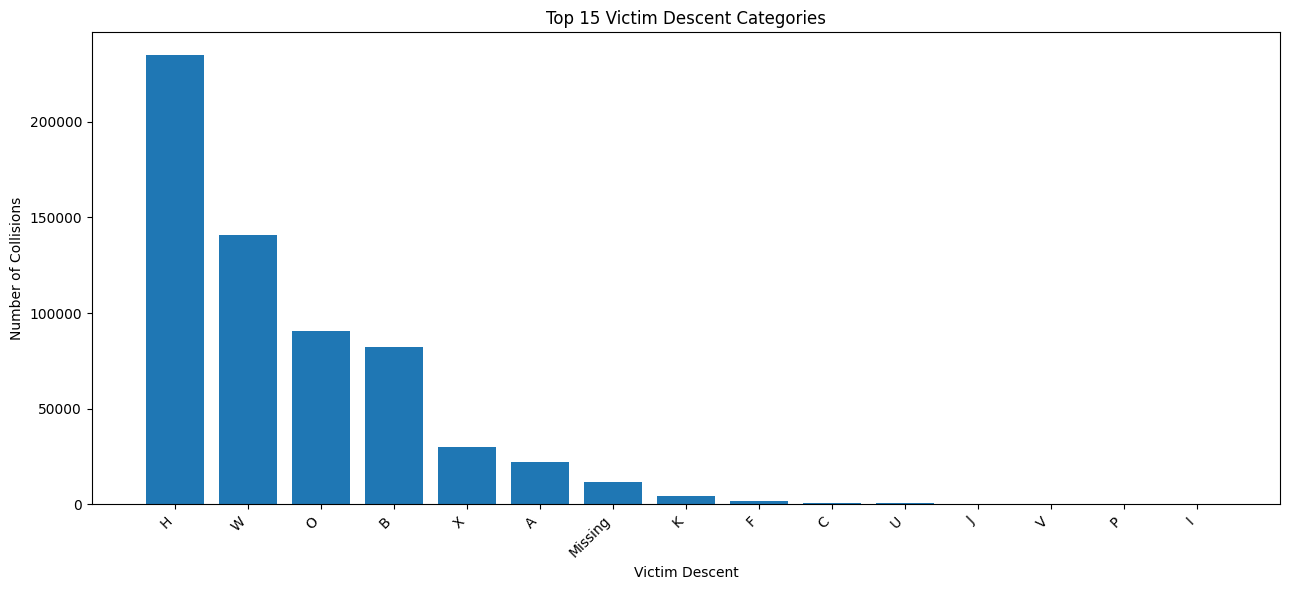


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_victim_descent_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_victim_descent_distribution.png


In [21]:
# ============================================================
# Step 11B — Victim Descent Analysis
# ============================================================

df_descent = df_eda.copy()

victim_descent_summary = (
    df_descent.groupby("victim_descent", dropna=False, as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

# readable label for missing
victim_descent_summary["victim_descent_label"] = victim_descent_summary["victim_descent"].astype(str)
victim_descent_summary.loc[
    victim_descent_summary["victim_descent"].isna(),
    "victim_descent_label"
] = "Missing"

victim_descent_summary["pct_of_total_collisions"] = (
    victim_descent_summary["total_collisions"] / victim_descent_summary["total_collisions"].sum() * 100
).round(2)

victim_descent_summary = (
    victim_descent_summary
    .sort_values("total_collisions", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("Victim Descent Distribution")
print("=" * 70)
display(victim_descent_summary.head(25)[["victim_descent_label", "total_collisions", "pct_of_total_collisions"]])

# ------------------------------------------------------------
# Plot top descent categories
# ------------------------------------------------------------
top_n = 15
descent_top = victim_descent_summary.head(top_n).copy()

plt.figure(figsize=(13, 6))
plt.bar(
    descent_top["victim_descent_label"].astype(str),
    descent_top["total_collisions"]
)

plt.title(f"Top {top_n} Victim Descent Categories")
plt.xlabel("Victim Descent")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

descent_fig_path = OUTPUT_FIGURES / "eda_victim_descent_distribution.png"
plt.savefig(descent_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
descent_table_path = OUTPUT_TABLES / "eda_victim_descent_distribution.csv"
victim_descent_summary.to_csv(descent_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(descent_table_path)
print(descent_fig_path)

## Step 11C — Victim Age Band Analysis

Exact age values are useful for detailed inspection, but grouped age bands are more suitable for interpretation, reporting, and dashboard communication.

This step groups valid victim ages into broader demographic bands in order to:
- identify the most affected age segments
- simplify demographic interpretation
- support executive storytelling and downstream BI usage

Victim Age Band Distribution


,age_band,total_collisions,pct_of_valid_age_records
0,0-17,2103,0.39
1,18-24,76107,14.27
2,25-34,141627,26.55
3,35-44,110644,20.74
4,45-54,94987,17.81
5,55-64,61596,11.55
6,65+,46419,8.70


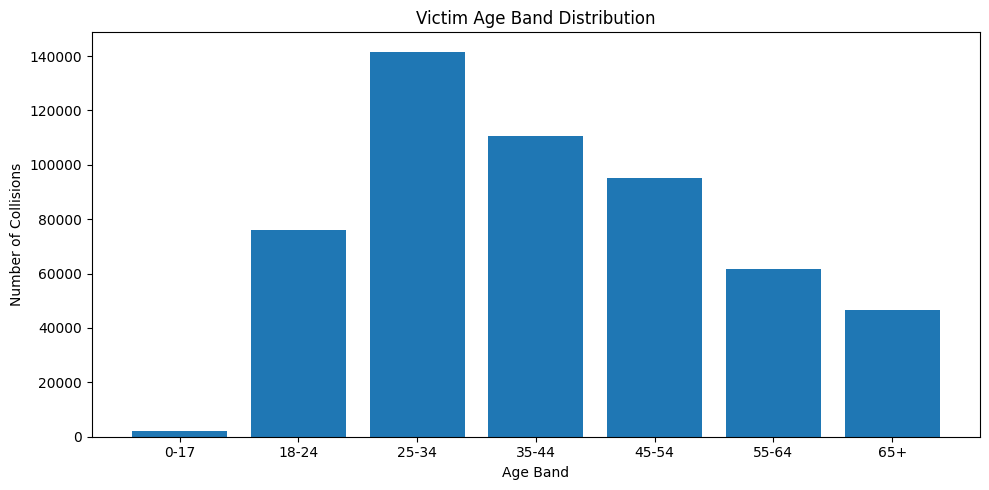


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_victim_age_band_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_victim_age_band_distribution.png


In [22]:
# ============================================================
# Step 11C — Victim Age Band Analysis
# ============================================================

df_age_bands = df_eda.copy()

# keep only valid ages
df_age_bands = df_age_bands[df_age_bands["victim_age"].notna()].copy()
df_age_bands = df_age_bands[
    (df_age_bands["victim_age"] >= 0) &
    (df_age_bands["victim_age"] <= 120)
].copy()

age_band_bins = [0, 17, 24, 34, 44, 54, 64, 120]
age_band_labels = [
    "0-17",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+",
]

df_age_bands["age_band"] = pd.cut(
    df_age_bands["victim_age"],
    bins=age_band_bins,
    labels=age_band_labels,
    right=True,
    include_lowest=True
)

age_band_summary = (
    df_age_bands.groupby("age_band", as_index=False)
    .agg(total_collisions=("dr_number", "count"))
)

age_band_summary["age_band"] = pd.Categorical(
    age_band_summary["age_band"],
    categories=age_band_labels,
    ordered=True
)

age_band_summary = age_band_summary.sort_values("age_band").reset_index(drop=True)

age_band_summary["pct_of_valid_age_records"] = (
    age_band_summary["total_collisions"] / age_band_summary["total_collisions"].sum() * 100
).round(2)

print("=" * 70)
print("Victim Age Band Distribution")
print("=" * 70)
display(age_band_summary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    age_band_summary["age_band"].astype(str),
    age_band_summary["total_collisions"]
)

plt.title("Victim Age Band Distribution")
plt.xlabel("Age Band")
plt.ylabel("Number of Collisions")
plt.tight_layout()

age_band_fig_path = OUTPUT_FIGURES / "eda_victim_age_band_distribution.png"
plt.savefig(age_band_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
age_band_table_path = OUTPUT_TABLES / "eda_victim_age_band_distribution.csv"
age_band_summary.to_csv(age_band_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(age_band_table_path)
print(age_band_fig_path)

## Step 12 — Outcome / Severity Field Discovery

Before starting severity and injury analysis, we first inspect which outcome-related fields are available in the cleaned analytical table.

This step is methodologically useful because field names may vary depending on the cleaning logic used in previous notebooks.

The goal is to identify columns related to:
- injury severity
- victim outcome
- hit and run
- pedestrian / bicycle flags
- any other collision consequence indicators

In [23]:
# ============================================================
# Step 12 — Outcome / Severity Field Discovery
# ============================================================

keywords = [
    "severity",
    "injury",
    "injured",
    "fatal",
    "death",
    "killed",
    "victim",
    "hit",
    "run",
    "ped",
    "bike",
    "bicycle",
]

matching_cols = []
for col in df_eda.columns:
    col_lower = col.lower()
    if any(k in col_lower for k in keywords):
        matching_cols.append(col)

outcome_fields_df = pd.DataFrame({
    "matching_columns": matching_cols
})

print("=" * 70)
print("Outcome / Severity Related Columns in df_eda")
print("=" * 70)
display(outcome_fields_df)

print("\nColumn count found:", len(matching_cols))

Outcome / Severity Related Columns in df_eda


,matching_columns
0,victim_age
1,is_valid_victim_age
2,victim_sex
3,is_valid_victim_sex_analytical
4,victim_descent
5,is_valid_victim_descent_analytical



Column count found: 6


## Step 13 — MO Analysis Framework Setup

The first MO-analysis attempt showed that not all MO-linked rows have the same analytical value.

Some rows represent direct collision signals that can be analyzed immediately, such as:
- collision counterpart / mode pairing
- injury severity
- hit-and-run status
- DUI / legality flags
- scene context such as intersection and property involvement

Other rows act more like structural or umbrella markers, such as:
- type of collision
- movement preceding collision
- primary collision factor family

In addition, some rows are peripheral or explicitly excluded from the main collision analysis.

Therefore, before continuing MO-based EDA, this step builds a structured MO analysis framework that separates:
- direct analytical signal rows
- anchor / structural rows
- peripheral or excluded rows

This will allow the next steps to focus only on the rows that carry real analytical insight.

In [24]:
# ============================================================
# Step 13 — MO Analysis Framework Setup
# ============================================================

df_mo_eda = df_bridge_mo.merge(
    df_dim_mo,
    on="mo_code",
    how="left",
    validate="many_to_one"
).copy()

print("=" * 70)
print("MO EDA Base Shape")
print("=" * 70)
print(df_mo_eda.shape)

# ------------------------------------------------------------
# Standardize helper text columns
# ------------------------------------------------------------
text_cols = [
    "mo_description",
    "analytical_category",
    "analytical_subcategory",
    "analytical_domain",
    "dashboard_group",
    "traffic_relevance_band",
    "keep_in_main_collision_dashboard",
    "recommended_use",
]

for col in text_cols:
    if col in df_mo_eda.columns:
        df_mo_eda[col] = df_mo_eda[col].astype(str).str.strip()

# ------------------------------------------------------------
# Rule 1: traffic-focused rows only
# ------------------------------------------------------------
traffic_core_mask = (
    df_mo_eda["traffic_relevance_band"].isin(["5 - Core", "4 - High supporting"])
)

dashboard_keep_mask = (
    df_mo_eda["keep_in_main_collision_dashboard"].str.upper().isin(["YES", "TRUE"])
)

domain_traffic_mask = (
    df_mo_eda["analytical_domain"].str.startswith("Traffic Collision", na=False)
    |
    df_mo_eda["dashboard_group"].isin([
        "Collision severity",
        "Collision offense flags",
        "Behavioral risk flags",
        "Geography / reporting area",
        "Scene context",
        "Licensing / legality",
        "Core collision analytics",
        "Causation / PCF",
        "Movement before impact",
        "Collision pattern",
        "Road user / transport profile",
        "Vulnerable road user context",
        "Vulnerable road user behavior",
    ])
)

df_mo_core = df_mo_eda[
    traffic_core_mask & dashboard_keep_mask & domain_traffic_mask
].copy()

# ------------------------------------------------------------
# Rule 2: identify anchor / structural MO rows
# ------------------------------------------------------------
anchor_codes = {3101, 3401, 3701}

anchor_desc_keywords = [
    "type of collision",
    "movement preceding collision",
    "primary collision factor",
]

anchor_subcat_keywords = [
    "type of collision",
    "movement preceding collision",
    "primary collision factor family",
]

anchor_mask = (
    df_mo_core["mo_code"].isin(anchor_codes)
    |
    df_mo_core["mo_description"].str.lower().str.contains(
        "|".join(anchor_desc_keywords),
        na=False
    )
    |
    df_mo_core["analytical_subcategory"].str.lower().str.contains(
        "|".join(anchor_subcat_keywords),
        na=False
    )
)

# ------------------------------------------------------------
# Rule 3: identify excluded / peripheral rows from full table
# ------------------------------------------------------------
peripheral_mask = (
    df_mo_eda["traffic_relevance_band"].isin(["0 - Exclude", "1 - Peripheral", "2 - Limited"])
    |
    (~df_mo_eda["keep_in_main_collision_dashboard"].str.upper().isin(["YES", "TRUE"]))
)

df_mo_anchor = df_mo_core[anchor_mask].copy()
df_mo_direct_signal = df_mo_core[~anchor_mask].copy()
df_mo_peripheral = df_mo_eda[peripheral_mask].copy()

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------
mo_framework_summary = pd.DataFrame({
    "bucket": [
        "all_mo_rows",
        "core_traffic_rows",
        "anchor_structural_rows",
        "direct_signal_rows",
        "peripheral_or_excluded_rows",
    ],
    "row_count": [
        len(df_mo_eda),
        len(df_mo_core),
        len(df_mo_anchor),
        len(df_mo_direct_signal),
        len(df_mo_peripheral),
    ],
    "unique_mo_codes": [
        df_mo_eda["mo_code"].nunique(),
        df_mo_core["mo_code"].nunique(),
        df_mo_anchor["mo_code"].nunique(),
        df_mo_direct_signal["mo_code"].nunique(),
        df_mo_peripheral["mo_code"].nunique(),
    ]
})

print("\n" + "=" * 70)
print("MO Analysis Framework Summary")
print("=" * 70)
display(mo_framework_summary)

print("\n" + "=" * 70)
print("Sample Direct Signal MO Rows")
print("=" * 70)
display(
    df_mo_direct_signal[
        [
            "dr_number",
            "mo_code",
            "mo_description",
            "analytical_category",
            "analytical_subcategory",
            "analytical_domain",
            "dashboard_group",
            "traffic_relevance_band",
        ]
    ].head(20)
)

print("\n" + "=" * 70)
print("Sample Anchor / Structural MO Rows")
print("=" * 70)
display(
    df_mo_anchor[
        [
            "dr_number",
            "mo_code",
            "mo_description",
            "analytical_category",
            "analytical_subcategory",
            "analytical_domain",
            "dashboard_group",
            "traffic_relevance_band",
        ]
    ].head(20)
)

print("\n" + "=" * 70)
print("Top Direct Signal MO Descriptions")
print("=" * 70)
top_direct_signal_preview = (
    df_mo_direct_signal.groupby("mo_description", as_index=False)
    .agg(total_rows=("dr_number", "count"))
    .sort_values("total_rows", ascending=False)
    .reset_index(drop=True)
)
display(top_direct_signal_preview.head(25))

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
framework_summary_path = OUTPUT_TABLES / "eda_mo_framework_summary.csv"
direct_signal_path = OUTPUT_TABLES / "eda_mo_direct_signal_rows.csv"
anchor_path = OUTPUT_TABLES / "eda_mo_anchor_rows.csv"
peripheral_path = OUTPUT_TABLES / "eda_mo_peripheral_rows.csv"
direct_preview_path = OUTPUT_TABLES / "eda_mo_direct_signal_preview.csv"

mo_framework_summary.to_csv(framework_summary_path, index=False)
df_mo_direct_signal.to_csv(direct_signal_path, index=False)
df_mo_anchor.to_csv(anchor_path, index=False)
df_mo_peripheral.to_csv(peripheral_path, index=False)
top_direct_signal_preview.to_csv(direct_preview_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(framework_summary_path)
print(direct_signal_path)
print(anchor_path)
print(peripheral_path)
print(direct_preview_path)

MO EDA Base Shape
(3523096, 17)

MO Analysis Framework Summary


,bucket,row_count,unique_mo_codes
0,all_mo_rows,3523096,346
1,core_traffic_rows,3402786,82
2,anchor_structural_rows,1209588,6
3,direct_signal_rows,2193198,76
4,peripheral_or_excluded_rows,26816,246



Sample Direct Signal MO Rows


,dr_number,mo_code,mo_description,analytical_category,analytical_subcategory,analytical_domain,dashboard_group,traffic_relevance_band
0,212013850,3004,T/C – Vehicle vs vehicle,Traffic Collision,Collision counterpart / mode pairing,Traffic Collision Core,Core collision analytics,5 - Core
1,212013850,3027,T/C – (K) Fatal injury,Traffic Collision,Injury severity,Traffic Collision Core,Collision severity,5 - Core
2,212013850,3034,T/C – City property involved: Yes,Traffic Collision,Scene context / property / intersection,Traffic Collision Core,Scene context,5 - Core
3,212013850,4027,T/C – West Traffic Division (WTD),Reporting Division,LAPD division / traffic division,Traffic Collision Jurisdiction,Geography / reporting area,5 - Core
4,212013850,3036,T/C – At intersection: Yes,Traffic Collision,Scene context / property / intersection,Traffic Collision Core,Scene context,5 - Core
8,221417787,4027,T/C – West Traffic Division (WTD),Reporting Division,LAPD division / traffic division,Traffic Collision Jurisdiction,Geography / reporting area,5 - Core
9,221417787,3011,T/C – Vehicle vs fixed object,Traffic Collision,Collision counterpart / mode pairing,Traffic Collision Core,Core collision analytics,5 - Core
10,221417787,3028,T/C – (N) Non-injury,Traffic Collision,Injury severity,Traffic Collision Core,Collision severity,5 - Core
11,221417787,3034,T/C – City property involved: Yes,Traffic Collision,Scene context / property / intersection,Traffic Collision Core,Scene context,5 - Core
12,221417787,3037,T/C – At intersection: No,Traffic Collision,Scene context / property / intersection,Traffic Collision Core,Scene context,5 - Core



Sample Anchor / Structural MO Rows


,dr_number,mo_code,mo_description,analytical_category,analytical_subcategory,analytical_domain,dashboard_group,traffic_relevance_band
5,212013850,3101,T/C – Primary collision factor (A) in narrative,Traffic Collision Cause,Primary collision factor family,Traffic Collision Causation,Causation / PCF,5 - Core
6,212013850,3401,T/C – Type of collision,Collision Pattern,Type of collision,Traffic Collision Type,Collision pattern,5 - Core
7,212013850,3701,T/C – Movement preceding collision,Pre-Collision Movement,Movement preceding collision,Traffic Collision Pre-Collision Movement,Movement before impact,5 - Core
13,221417787,3101,T/C – Primary collision factor (A) in narrative,Traffic Collision Cause,Primary collision factor family,Traffic Collision Causation,Causation / PCF,5 - Core
14,221417787,3401,T/C – Type of collision,Collision Pattern,Type of collision,Traffic Collision Type,Collision pattern,5 - Core
15,221417787,3701,T/C – Movement preceding collision,Pre-Collision Movement,Movement preceding collision,Traffic Collision Pre-Collision Movement,Movement before impact,5 - Core
21,221418141,3101,T/C – Primary collision factor (A) in narrative,Traffic Collision Cause,Primary collision factor family,Traffic Collision Causation,Causation / PCF,5 - Core
22,221418141,3401,T/C – Type of collision,Collision Pattern,Type of collision,Traffic Collision Type,Collision pattern,5 - Core
23,221418141,3701,T/C – Movement preceding collision,Pre-Collision Movement,Movement preceding collision,Traffic Collision Pre-Collision Movement,Movement before impact,5 - Core
29,222017859,3101,T/C – Primary collision factor (A) in narrative,Traffic Collision Cause,Primary collision factor family,Traffic Collision Causation,Causation / PCF,5 - Core



Top Direct Signal MO Descriptions


,mo_description,total_rows
0,T/C – Vehicle vs vehicle,268791
1,T/C – At intersection: No,252159
2,T/C – Hit and run (misdemeanor),204190
3,T/C – (N) Non-injury,184098
4,T/C – (C) Complaint of injury,148649
5,T/C – At intersection: Yes,131369
6,T/C – Vehicle vs parked vehicle,118445
7,T/C – City property involved: No,110619
8,T/C – Valley Traffic Division (VTD),94376
9,T/C – City property involved: Yes,77515



----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_framework_summary.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_direct_signal_rows.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_anchor_rows.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_peripheral_rows.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_direct_signal_preview.csv


## Step 13A — Direct Signal MO Distribution

After separating structural anchor rows from direct analytical signal rows, this step summarizes the most frequent direct-signal MO descriptions.

The objectives are to:
- identify the most common actionable MO signals in the collision data
- separate high-frequency collision insights from generic structural markers
- establish the main MO-based analytical themes before drilling into specific groups such as severity, hit-and-run, and collision counterpart patterns

This is the first direct MO insight layer built from analytically usable rows only.

Direct Signal MO Distribution


,mo_code,mo_description,analytical_category,analytical_subcategory,analytical_domain,dashboard_group,total_rows,pct_of_direct_signal_rows
0,3004,T/C – Vehicle vs vehicle,Traffic Collision,Collision counterpart / mode pairing,Traffic Collision Core,Core collision analytics,268791,12.26
1,3037,T/C – At intersection: No,Traffic Collision,Scene context / property / intersection,Traffic Collision Core,Scene context,252159,11.50
2,3030,T/C – Hit and run (misdemeanor),Traffic Collision,Hit-and-run status,Traffic Collision Core,Collision offense flags,204190,9.31
3,3028,T/C – (N) Non-injury,Traffic Collision,Injury severity,Traffic Collision Core,Collision severity,184098,8.39
4,3026,T/C – (C) Complaint of injury,Traffic Collision,Injury severity,Traffic Collision Core,Collision severity,148649,6.78
5,3036,T/C – At intersection: Yes,Traffic Collision,Scene context / property / intersection,Traffic Collision Core,Scene context,131369,5.99
6,3006,T/C – Vehicle vs parked vehicle,Traffic Collision,Collision counterpart / mode pairing,Traffic Collision Core,Core collision analytics,118445,5.40
7,3035,T/C – City property involved: No,Traffic Collision,Scene context / property / intersection,Traffic Collision Core,Scene context,110619,5.04
8,4026,T/C – Valley Traffic Division (VTD),Reporting Division,LAPD division / traffic division,Traffic Collision Jurisdiction,Geography / reporting area,94376,4.30
9,3034,T/C – City property involved: Yes,Traffic Collision,Scene context / property / intersection,Traffic Collision Core,Scene context,77515,3.53


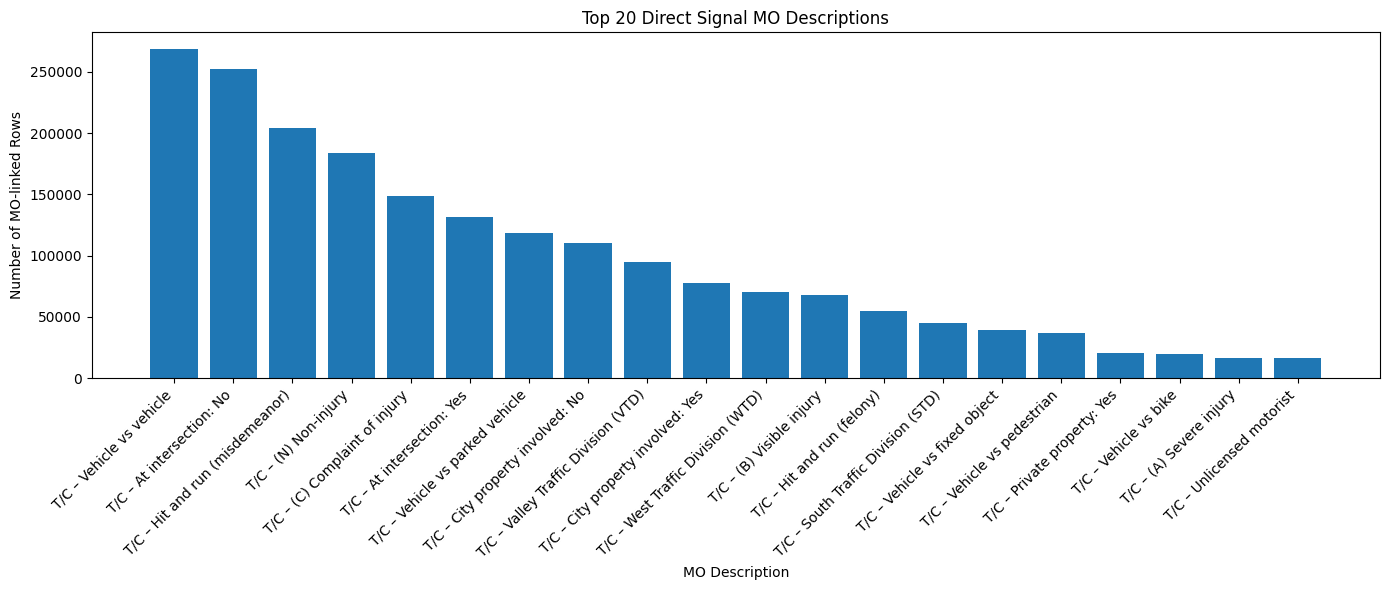


Direct Signal MO Distribution — By Analytical Subcategory


,analytical_subcategory,total_rows,pct_of_direct_signal_rows
0,Scene context / property / intersection,607186,27.68
1,Collision counterpart / mode pairing,504375,23.00
2,Injury severity,419994,19.15
3,LAPD division / traffic division,372037,16.96
4,Hit-and-run status,258982,11.81
5,Unlicensed motorist,16033,0.73
6,DUI status,10607,0.48
7,Driver sobriety,2334,0.11
8,Pedestrian actions,648,0.03
9,Other special factor,517,0.02



----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_direct_signal_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_direct_signal_subcategory_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_mo_direct_signal_distribution.png


In [25]:
# ============================================================
# Step 13A — Direct Signal MO Distribution
# ============================================================

direct_signal_summary = (
    df_mo_direct_signal.groupby(
        [
            "mo_code",
            "mo_description",
            "analytical_category",
            "analytical_subcategory",
            "analytical_domain",
            "dashboard_group",
        ],
        as_index=False
    )
    .agg(total_rows=("dr_number", "count"))
    .sort_values("total_rows", ascending=False)
    .reset_index(drop=True)
)

direct_signal_summary["pct_of_direct_signal_rows"] = (
    direct_signal_summary["total_rows"] / direct_signal_summary["total_rows"].sum() * 100
).round(2)

print("=" * 70)
print("Direct Signal MO Distribution")
print("=" * 70)
display(direct_signal_summary.head(30))

# ------------------------------------------------------------
# Plot top direct signal descriptions
# ------------------------------------------------------------
top_n = 20
direct_signal_top = direct_signal_summary.head(top_n).copy()

plt.figure(figsize=(14, 6))
plt.bar(
    direct_signal_top["mo_description"].astype(str),
    direct_signal_top["total_rows"]
)

plt.title(f"Top {top_n} Direct Signal MO Descriptions")
plt.xlabel("MO Description")
plt.ylabel("Number of MO-linked Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

direct_signal_fig_path = OUTPUT_FIGURES / "eda_mo_direct_signal_distribution.png"
plt.savefig(direct_signal_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Analytical bucket preview by subcategory
# ------------------------------------------------------------
direct_signal_subcat_summary = (
    df_mo_direct_signal.groupby(
        ["analytical_subcategory"],
        as_index=False
    )
    .agg(total_rows=("dr_number", "count"))
    .sort_values("total_rows", ascending=False)
    .reset_index(drop=True)
)

direct_signal_subcat_summary["pct_of_direct_signal_rows"] = (
    direct_signal_subcat_summary["total_rows"] / direct_signal_subcat_summary["total_rows"].sum() * 100
).round(2)

print("\n" + "=" * 70)
print("Direct Signal MO Distribution — By Analytical Subcategory")
print("=" * 70)
display(direct_signal_subcat_summary.head(20))

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
direct_signal_summary_path = OUTPUT_TABLES / "eda_mo_direct_signal_distribution.csv"
direct_signal_subcat_summary_path = OUTPUT_TABLES / "eda_mo_direct_signal_subcategory_distribution.csv"

direct_signal_summary.to_csv(direct_signal_summary_path, index=False)
direct_signal_subcat_summary.to_csv(direct_signal_subcat_summary_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(direct_signal_summary_path)
print(direct_signal_subcat_summary_path)
print(direct_signal_fig_path)

## Step 13B — Collision Counterpart / Mode Pairing Analysis

This section focuses on direct-signal MO rows classified under collision counterpart and mode pairing.

The objectives are to:
- identify the most common counterpart patterns in recorded collisions
- quantify how often collisions involve vehicles, parked vehicles, pedestrians, bicycles, motorcycles, and fixed objects
- establish one of the clearest behavioral and roadway-interaction views in the MO layer

This is one of the strongest MO-based insight sections because the descriptions are direct, interpretable, and collision-specific.

Collision Counterpart / Mode Pairing Summary


,mo_code,mo_description,total_rows,pct_of_counterpart_rows
0,3004,T/C – Vehicle vs vehicle,268791,53.29
1,3006,T/C – Vehicle vs parked vehicle,118445,23.48
2,3011,T/C – Vehicle vs fixed object,38860,7.70
3,3003,T/C – Vehicle vs pedestrian,36900,7.32
4,3008,T/C – Vehicle vs bike,19720,3.91
5,3009,T/C – Vehicle vs motorcycle,8114,1.61
6,3002,T/C – Officer involved traffic collision,6405,1.27
7,3012,T/C – Vehicle vs other object,1849,0.37
8,3016,T/C – Bike vs vehicle,1452,0.29
9,3013,T/C – Motorcycle vs vehicle,754,0.15


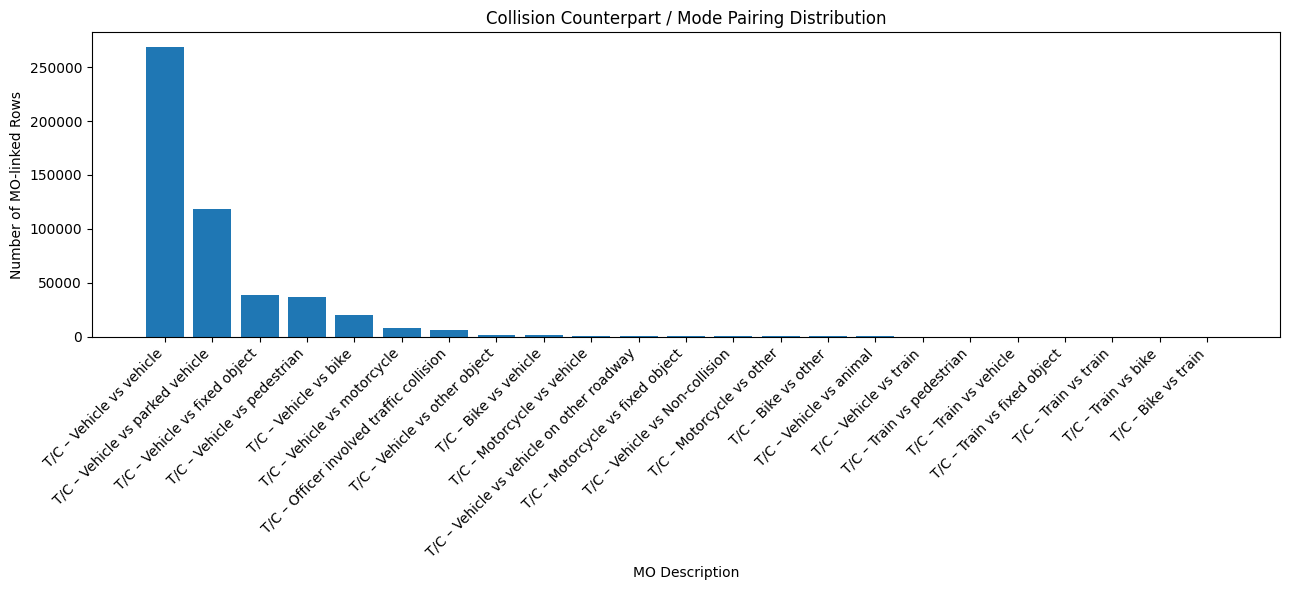


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_collision_counterpart_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_mo_collision_counterpart_distribution.png


In [26]:
# ============================================================
# Step 13B — Collision Counterpart / Mode Pairing Analysis
# ============================================================

df_mo_counterpart = df_mo_direct_signal[
    df_mo_direct_signal["analytical_subcategory"] == "Collision counterpart / mode pairing"
].copy()

counterpart_summary = (
    df_mo_counterpart.groupby(
        ["mo_code", "mo_description"],
        as_index=False
    )
    .agg(total_rows=("dr_number", "count"))
    .sort_values("total_rows", ascending=False)
    .reset_index(drop=True)
)

counterpart_summary["pct_of_counterpart_rows"] = (
    counterpart_summary["total_rows"] / counterpart_summary["total_rows"].sum() * 100
).round(2)

print("=" * 70)
print("Collision Counterpart / Mode Pairing Summary")
print("=" * 70)
display(counterpart_summary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(13, 6))
plt.bar(
    counterpart_summary["mo_description"].astype(str),
    counterpart_summary["total_rows"]
)

plt.title("Collision Counterpart / Mode Pairing Distribution")
plt.xlabel("MO Description")
plt.ylabel("Number of MO-linked Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

counterpart_fig_path = OUTPUT_FIGURES / "eda_mo_collision_counterpart_distribution.png"
plt.savefig(counterpart_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
counterpart_table_path = OUTPUT_TABLES / "eda_mo_collision_counterpart_distribution.csv"
counterpart_summary.to_csv(counterpart_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(counterpart_table_path)
print(counterpart_fig_path)

## Step 13C — Injury Severity Analysis via MO Codes

This section analyzes direct-signal MO rows classified under injury severity.

The objectives are to:
- quantify the relative distribution of injury outcomes
- distinguish between non-injury, complaint of injury, visible injury, severe injury, and fatal injury
- provide a clear severity profile from the MO layer

This is one of the most important MO-based sections because it directly supports collision severity storytelling and dashboard design.

Injury Severity Summary via MO


,mo_code,mo_description,total_rows,pct_of_severity_rows
0,3028,T/C – (N) Non-injury,184098,43.83
1,3026,T/C – (C) Complaint of injury,148649,35.39
2,3025,T/C – (B) Visible injury,67523,16.08
3,3024,T/C – (A) Severe injury,16376,3.90
4,3027,T/C – (K) Fatal injury,3348,0.80


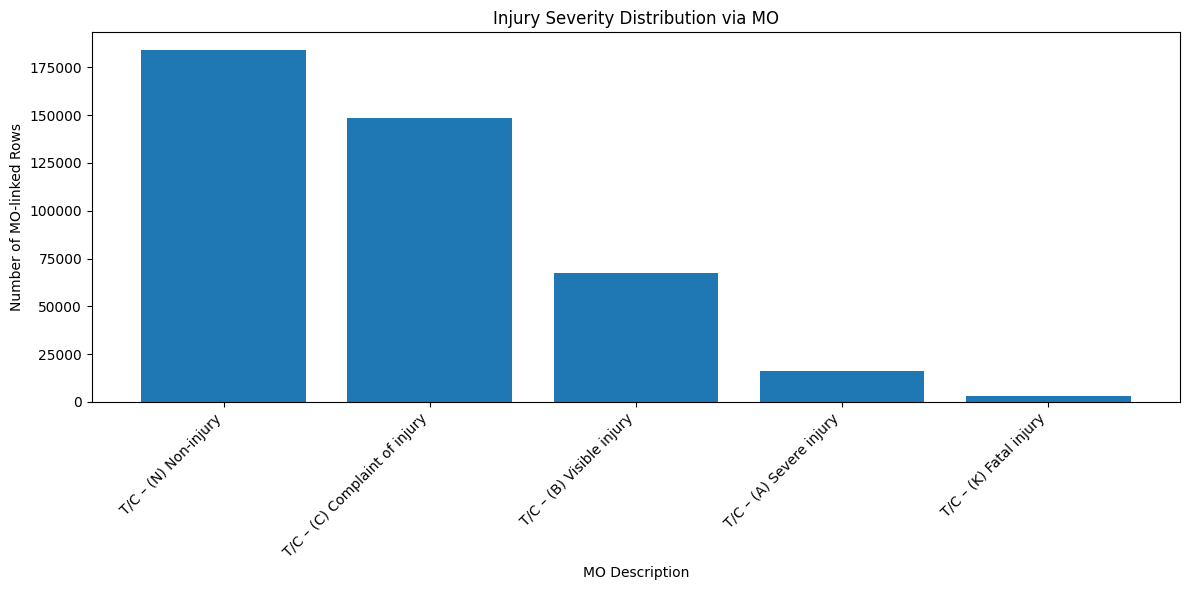


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_injury_severity_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_mo_injury_severity_distribution.png


In [27]:
# ============================================================
# Step 13C — Injury Severity Analysis via MO Codes
# ============================================================

df_mo_severity = df_mo_direct_signal[
    df_mo_direct_signal["analytical_subcategory"] == "Injury severity"
].copy()

severity_summary = (
    df_mo_severity.groupby(
        ["mo_code", "mo_description"],
        as_index=False
    )
    .agg(total_rows=("dr_number", "count"))
    .sort_values("total_rows", ascending=False)
    .reset_index(drop=True)
)

severity_summary["pct_of_severity_rows"] = (
    severity_summary["total_rows"] / severity_summary["total_rows"].sum() * 100
).round(2)

print("=" * 70)
print("Injury Severity Summary via MO")
print("=" * 70)
display(severity_summary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.bar(
    severity_summary["mo_description"].astype(str),
    severity_summary["total_rows"]
)

plt.title("Injury Severity Distribution via MO")
plt.xlabel("MO Description")
plt.ylabel("Number of MO-linked Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

severity_fig_path = OUTPUT_FIGURES / "eda_mo_injury_severity_distribution.png"
plt.savefig(severity_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
severity_table_path = OUTPUT_TABLES / "eda_mo_injury_severity_distribution.csv"
severity_summary.to_csv(severity_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(severity_table_path)
print(severity_fig_path)

## Step 13D — Hit-and-Run Analysis via MO Codes

This section analyzes direct-signal MO rows classified under hit-and-run status.

The objectives are to:
- quantify the distribution of hit-and-run cases
- distinguish between misdemeanor and felony hit-and-run signals
- support a clear view of collision offense behavior within the MO layer

This section is especially useful because hit-and-run appears frequently in the direct-signal MO distribution and has strong reporting value.

Hit-and-Run Summary via MO


,mo_code,mo_description,total_rows,pct_of_hit_run_rows
0,3030,T/C – Hit and run (misdemeanor),204190,78.84
1,3029,T/C – Hit and run (felony),54792,21.16


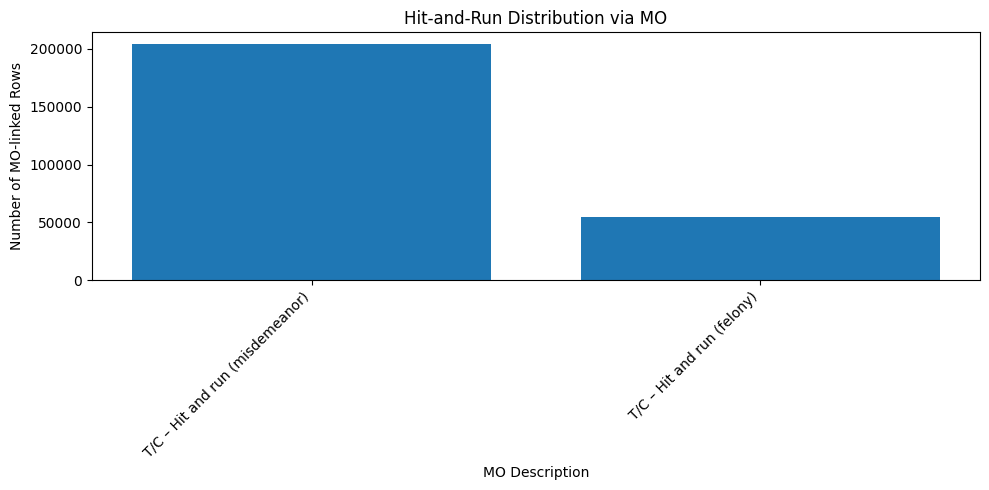


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_hit_and_run_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_mo_hit_and_run_distribution.png


In [28]:
# ============================================================
# Step 13D — Hit-and-Run Analysis via MO Codes
# ============================================================

df_mo_hit_run = df_mo_direct_signal[
    df_mo_direct_signal["analytical_subcategory"] == "Hit-and-run status"
].copy()

hit_run_summary = (
    df_mo_hit_run.groupby(
        ["mo_code", "mo_description"],
        as_index=False
    )
    .agg(total_rows=("dr_number", "count"))
    .sort_values("total_rows", ascending=False)
    .reset_index(drop=True)
)

hit_run_summary["pct_of_hit_run_rows"] = (
    hit_run_summary["total_rows"] / hit_run_summary["total_rows"].sum() * 100
).round(2)

print("=" * 70)
print("Hit-and-Run Summary via MO")
print("=" * 70)
display(hit_run_summary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    hit_run_summary["mo_description"].astype(str),
    hit_run_summary["total_rows"]
)

plt.title("Hit-and-Run Distribution via MO")
plt.xlabel("MO Description")
plt.ylabel("Number of MO-linked Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

hit_run_fig_path = OUTPUT_FIGURES / "eda_mo_hit_and_run_distribution.png"
plt.savefig(hit_run_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
hit_run_table_path = OUTPUT_TABLES / "eda_mo_hit_and_run_distribution.csv"
hit_run_summary.to_csv(hit_run_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(hit_run_table_path)
print(hit_run_fig_path)

## Step 13E — Scene Context Analysis via MO Codes

This section analyzes direct-signal MO rows related to scene context, especially:
- intersection involvement
- city property involvement
- private property involvement

The objectives are to:
- understand the most common scene-context flags linked to recorded collisions
- distinguish between intersection and non-intersection settings
- examine how often city or private property is involved

This section adds an important environmental and situational layer to the MO-based collision analysis.

Scene Context Summary via MO


,mo_code,mo_description,total_rows,pct_of_scene_context_rows
0,3037,T/C – At intersection: No,252159,41.53
1,3036,T/C – At intersection: Yes,131369,21.64
2,3035,T/C – City property involved: No,110619,18.22
3,3034,T/C – City property involved: Yes,77515,12.77
4,3032,T/C – Private property: Yes,20587,3.39
5,3033,T/C – Private property: No,14937,2.46


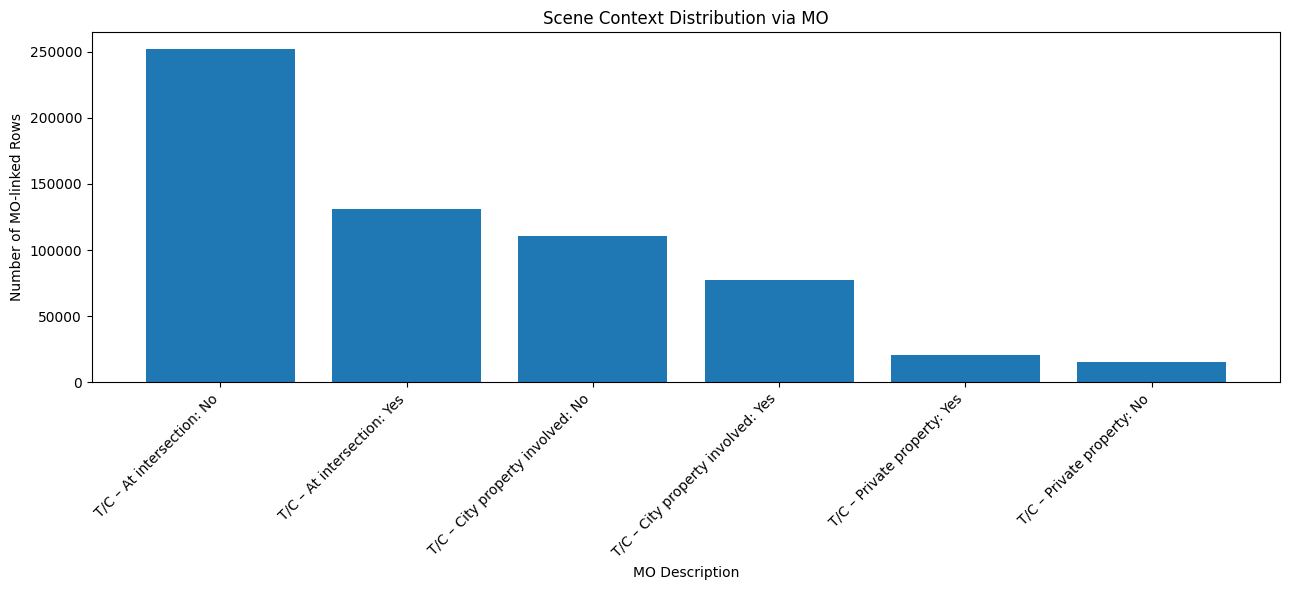


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_scene_context_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_mo_scene_context_distribution.png


In [29]:
# ============================================================
# Step 13E — Scene Context Analysis via MO Codes
# ============================================================

df_mo_scene = df_mo_direct_signal[
    df_mo_direct_signal["analytical_subcategory"] == "Scene context / property / intersection"
].copy()

scene_context_summary = (
    df_mo_scene.groupby(
        ["mo_code", "mo_description"],
        as_index=False
    )
    .agg(total_rows=("dr_number", "count"))
    .sort_values("total_rows", ascending=False)
    .reset_index(drop=True)
)

scene_context_summary["pct_of_scene_context_rows"] = (
    scene_context_summary["total_rows"] / scene_context_summary["total_rows"].sum() * 100
).round(2)

print("=" * 70)
print("Scene Context Summary via MO")
print("=" * 70)
display(scene_context_summary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(13, 6))
plt.bar(
    scene_context_summary["mo_description"].astype(str),
    scene_context_summary["total_rows"]
)

plt.title("Scene Context Distribution via MO")
plt.xlabel("MO Description")
plt.ylabel("Number of MO-linked Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

scene_context_fig_path = OUTPUT_FIGURES / "eda_mo_scene_context_distribution.png"
plt.savefig(scene_context_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
scene_context_table_path = OUTPUT_TABLES / "eda_mo_scene_context_distribution.csv"
scene_context_summary.to_csv(scene_context_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(scene_context_table_path)
print(scene_context_fig_path)

## Step 13F — Jurisdiction / Reporting Division Analysis via MO Codes

This section analyzes direct-signal MO rows related to LAPD reporting and traffic divisions.

The objectives are to:
- identify which traffic and reporting divisions appear most frequently in the MO layer
- compare division-level collision burden from the MO-coded perspective
- add an administrative and jurisdictional view to the MO-based analysis

This step complements the earlier area and reporting-district analysis by introducing the division logic embedded in the MO records.

Jurisdiction / Reporting Division Summary via MO


,mo_code,mo_description,total_rows,pct_of_jurisdiction_rows
0,4026,T/C – Valley Traffic Division (VTD),94376,25.37
1,4027,T/C – West Traffic Division (WTD),69973,18.81
2,4025,T/C – South Traffic Division (STD),44635,12.00
3,4024,T/C – Central Traffic Division (CTD),15124,4.07
4,4020,T/C – Olympic Division,11407,3.07
5,4012,T/C – 77th Street Division,11113,2.99
6,4014,T/C – Pacific Division,10824,2.91
7,4008,T/C – West Los Angeles Division,10816,2.91
8,4006,T/C – Hollywood Division,10807,2.90
9,4015,T/C – North Hollywood Division,9965,2.68


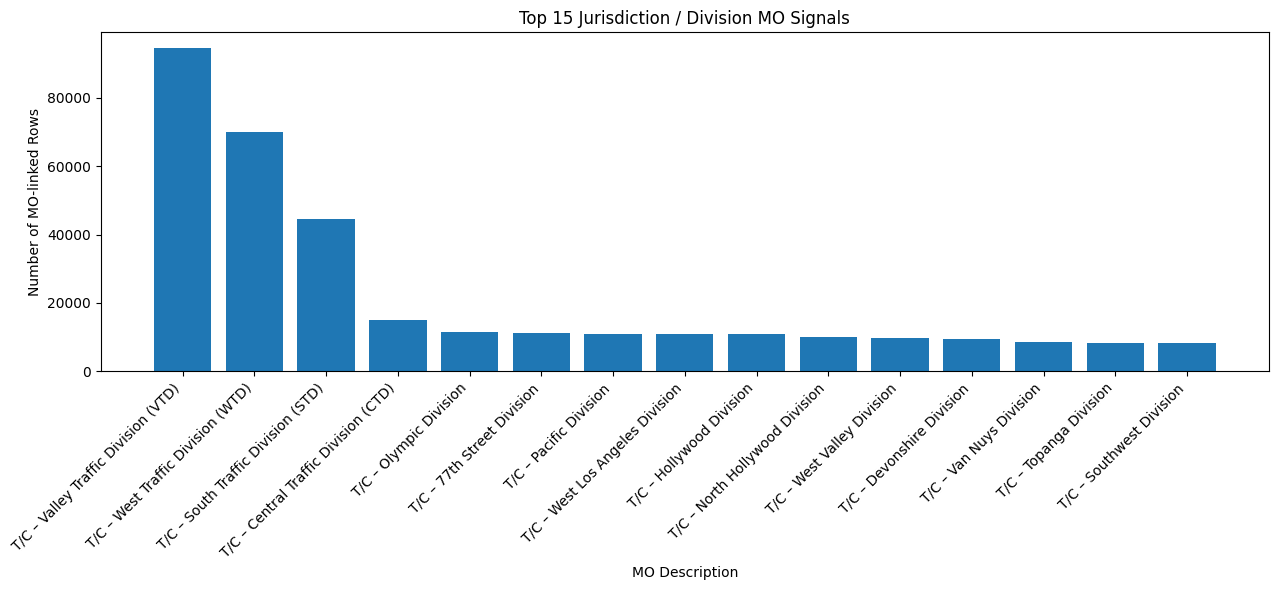


----------------------------------------------------------------------
Saved outputs:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_mo_jurisdiction_distribution.csv
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\eda\eda_mo_jurisdiction_distribution.png


In [30]:
# ============================================================
# Step 13F — Jurisdiction / Reporting Division Analysis via MO
# ============================================================

df_mo_jurisdiction = df_mo_direct_signal[
    df_mo_direct_signal["analytical_subcategory"] == "LAPD division / traffic division"
].copy()

jurisdiction_summary = (
    df_mo_jurisdiction.groupby(
        ["mo_code", "mo_description"],
        as_index=False
    )
    .agg(total_rows=("dr_number", "count"))
    .sort_values("total_rows", ascending=False)
    .reset_index(drop=True)
)

jurisdiction_summary["pct_of_jurisdiction_rows"] = (
    jurisdiction_summary["total_rows"] / jurisdiction_summary["total_rows"].sum() * 100
).round(2)

print("=" * 70)
print("Jurisdiction / Reporting Division Summary via MO")
print("=" * 70)
display(jurisdiction_summary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
top_n = 15
jurisdiction_top = jurisdiction_summary.head(top_n).copy()

plt.figure(figsize=(13, 6))
plt.bar(
    jurisdiction_top["mo_description"].astype(str),
    jurisdiction_top["total_rows"]
)

plt.title(f"Top {top_n} Jurisdiction / Division MO Signals")
plt.xlabel("MO Description")
plt.ylabel("Number of MO-linked Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

jurisdiction_fig_path = OUTPUT_FIGURES / "eda_mo_jurisdiction_distribution.png"
plt.savefig(jurisdiction_fig_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
jurisdiction_table_path = OUTPUT_TABLES / "eda_mo_jurisdiction_distribution.csv"
jurisdiction_summary.to_csv(jurisdiction_table_path, index=False)

print("\n" + "-" * 70)
print("Saved outputs:")
print(jurisdiction_table_path)
print(jurisdiction_fig_path)

## MO Insight Summary Note

The refined MO analysis framework successfully separated analytically useful traffic-collision signals from structural and peripheral MO rows.

Key MO-based findings from the direct-signal layer include:

- The most common collision counterpart pattern is `Vehicle vs vehicle`, followed by `Vehicle vs parked vehicle`
- The injury profile is led by `Non-injury` and `Complaint of injury`, while `Severe injury` and `Fatal injury` form a much smaller but important subset
- Hit-and-run signals are frequent, with `misdemeanor` cases substantially exceeding `felony` cases
- Scene context signals indicate that non-intersection cases exceed intersection cases in the MO-coded layer
- Jurisdictional MO signals are concentrated most heavily in `Valley Traffic Division`, `West Traffic Division`, and `South Traffic Division`

Analytical implication:
The MO layer is highly valuable when analyzed through direct-signal filtering. Without that filtering, structural anchor rows dominate and obscure the underlying collision patterns. With the refined approach, the MO data becomes one of the strongest contextual enrichment layers in the notebook.

## Step 14 — Notebook 04 Final Insight Summary

This notebook transformed the cleaned collision tables into an interpretable exploratory analysis layer.

The analysis covered five main perspectives:

### 1. Structural and analytical readiness
- the cleaned collision table was structurally validated
- critical fields were checked for completeness and usability
- time fields were converted and confirmed to be analysis-ready

### 2. Temporal behavior
- annual trend analysis showed a long-term rise through the mid/late 2010s, followed by a major drop in the early 2020s
- monthly and weekday analysis revealed clear temporal concentration patterns
- hourly and time-band analysis showed a strong afternoon and evening peak, especially on Fridays
- weekday × hour heatmaps confirmed that Friday afternoon / evening is one of the strongest temporal hotspots

### 3. Geographic distribution
- area-level analysis showed meaningful concentration, but not extreme monopoly by a single area
- reporting-district analysis added more granular geographic differentiation
- premise analysis confirmed that `STREET` overwhelmingly dominates the dataset, with `PARKING LOT` emerging as the leading non-street context

### 4. Victim profile
- the victim profile is concentrated primarily in working-age adults
- the `25–34` band is the most affected, followed by `35–44` and `45–54`
- male victims represent the largest share
- victim descent distribution is clearly structured, with a limited proportion of missing values

### 5. MO-based collision context
- the initial MO approach was refined by separating direct-signal rows from structural anchor rows
- this made it possible to extract interpretable insights from MO-coded counterpart patterns, injury severity, hit-and-run, scene context, and jurisdictional indicators
- the MO layer proved highly useful once analyzed through signal-oriented filtering rather than broad aggregate domain summaries

Overall conclusion:
Notebook 04 successfully established the core exploratory narrative of the project and produced a strong analytical base for downstream aggregation, SQL modeling, dashboard preparation, and final reporting.

In [31]:
# ============================================================
# Step 14 — Notebook 04 Outputs Recap
# ============================================================

eda_output_files = [
    "eda_collisions_dtype_missing_summary.csv",
    "eda_structural_validation_checks.csv",
    "eda_critical_fields_missing_summary.csv",
    "eda_date_conversion_summary.csv",
    "eda_time_readiness_check.csv",
    "eda_collision_overview_kpis.csv",
    "eda_annual_collision_trend.csv",
    "eda_year_coverage_summary.csv",
    "eda_annual_collision_trend_full_years_only.csv",
    "eda_monthly_collision_distribution.csv",
    "eda_monthly_collisions_by_year_full_years.csv",
    "eda_monthly_seasonality_full_years_only.csv",
    "eda_monthly_heatmap_by_year.csv",
    "eda_weekday_collision_distribution.csv",
    "eda_hourly_collision_distribution.csv",
    "eda_time_band_collision_distribution.csv",
    "eda_weekday_hour_heatmap.csv",
    "eda_area_collision_distribution.csv",
    "eda_reporting_district_collision_distribution.csv",
    "eda_premise_collision_distribution.csv",
    "eda_premise_collision_distribution_excluding_street.csv",
    "eda_victim_age_summary.csv",
    "eda_victim_age_distribution.csv",
    "eda_victim_sex_distribution.csv",
    "eda_victim_descent_distribution.csv",
    "eda_victim_age_band_distribution.csv",
    "eda_mo_framework_summary.csv",
    "eda_mo_direct_signal_rows.csv",
    "eda_mo_anchor_rows.csv",
    "eda_mo_peripheral_rows.csv",
    "eda_mo_direct_signal_preview.csv",
    "eda_mo_direct_signal_distribution.csv",
    "eda_mo_direct_signal_subcategory_distribution.csv",
    "eda_mo_collision_counterpart_distribution.csv",
    "eda_mo_injury_severity_distribution.csv",
    "eda_mo_hit_and_run_distribution.csv",
    "eda_mo_scene_context_distribution.csv",
    "eda_mo_jurisdiction_distribution.csv",
]

eda_output_status = pd.DataFrame({
    "file_name": eda_output_files
})

eda_output_status["exists"] = eda_output_status["file_name"].apply(
    lambda x: (OUTPUT_TABLES / x).exists()
)

print("=" * 70)
print("Notebook 04 Output Files Status")
print("=" * 70)
display(eda_output_status)

print("\n" + "=" * 70)
print("Notebook 04 Completion Summary")
print("=" * 70)
print(f"Total expected output tables checked: {len(eda_output_status)}")
print(f"Tables found: {eda_output_status['exists'].sum()}")
print(f"Tables missing: {(~eda_output_status['exists']).sum()}")

notebook04_status_path = OUTPUT_TABLES / "eda_notebook04_output_status.csv"
eda_output_status.to_csv(notebook04_status_path, index=False)

print("\nSaved output:")
print(notebook04_status_path)

Notebook 04 Output Files Status


,file_name,exists
0,eda_collisions_dtype_missing_summary.csv,True
1,eda_structural_validation_checks.csv,True
2,eda_critical_fields_missing_summary.csv,True
3,eda_date_conversion_summary.csv,True
4,eda_time_readiness_check.csv,True
5,eda_collision_overview_kpis.csv,True
6,eda_annual_collision_trend.csv,True
7,eda_year_coverage_summary.csv,True
8,eda_annual_collision_trend_full_years_only.csv,True
9,eda_monthly_collision_distribution.csv,True



Notebook 04 Completion Summary
Total expected output tables checked: 38
Tables found: 38
Tables missing: 0

Saved output:
C:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\eda\eda_notebook04_output_status.csv


## MO Insight Summary Note

The refined MO analysis framework successfully separated analytically useful traffic-collision signals from structural anchor rows and peripheral records.

Key MO-based findings from the direct-signal layer include:

- `Vehicle vs vehicle` is the dominant collision counterpart pattern, followed by `Vehicle vs parked vehicle`
- The severity profile is led by `Non-injury` and `Complaint of injury`, while `Severe injury` and `Fatal injury` represent a much smaller but still important subset
- Hit-and-run signals are frequent, with `misdemeanor` cases far exceeding `felony` cases
- Scene-context signals show that non-intersection cases exceed intersection cases in the MO-coded layer
- Jurisdictional MO signals are most concentrated in `Valley Traffic Division`, followed by `West Traffic Division` and `South Traffic Division`

Analytical implication:

The MO layer becomes highly valuable once direct-signal rows are isolated from structural anchor rows. Without this refinement, generic marker rows dominate the analysis and obscure the actual collision patterns. With the refined approach, the MO data provides one of the strongest contextual enrichment layers in the notebook.

## Step 14 — Notebook 04 Final Insight Summary

This notebook transformed the cleaned collision tables into a structured exploratory analysis layer and established the main analytical narrative of the project.

### 1. Structural and analytical readiness
- the cleaned collision table was structurally validated
- key fields were checked for completeness and usability
- time fields were converted and confirmed to be analysis-ready

### 2. Temporal behavior
- annual trend analysis showed a long rise through the mid and late 2010s, followed by a sharp decline in the early 2020s
- monthly distribution indicated modest seasonality rather than extreme month-to-month concentration
- weekday analysis showed Friday as the strongest day
- hourly and time-band analysis showed the strongest concentration from afternoon into evening
- weekday × hour analysis confirmed Friday afternoon / evening as one of the clearest temporal hotspots

### 3. Geographic distribution
- area-level analysis showed concentration in some LAPD areas, but not an extreme monopoly by a single area
- reporting-district analysis added finer local differentiation
- premise analysis confirmed that `STREET` overwhelmingly dominates the collision environment, while `PARKING LOT` becomes the leading non-street context after excluding `STREET`

### 4. Victim profile
- the victim profile is concentrated primarily in working-age adults
- the `25–34` age band is the largest, followed by `35–44` and `45–54`
- male victims represent the largest share
- victim descent distribution is clearly structured with limited missingness

### 5. MO-based collision context
- the initial MO approach was refined by separating direct-signal rows from structural anchor rows
- this made it possible to extract interpretable insights on counterpart patterns, injury severity, hit-and-run, scene context, and jurisdictional signals
- the MO layer proved highly valuable once analyzed through signal-oriented filtering rather than broad domain-only summaries

Overall conclusion:

Notebook 04 successfully established the core exploratory narrative of the project and produced a strong analytical base for downstream aggregation, SQL modeling, dashboard preparation, and final reporting.

## Notebook 04 Conclusion

Notebook 04 completed the core exploratory data analysis phase of the LA Traffic Collision project.

The notebook confirmed that the dataset is analytically usable and revealed consistent patterns across time, geography, victim profile, and MO-coded collision context.

The most important high-level conclusions are:

- collisions are not distributed uniformly across time; they concentrate strongly in afternoon and evening periods, especially on Fridays
- the spatial burden is distributed across multiple areas and reporting districts rather than being dominated by a single location
- the roadway environment is overwhelmingly street-based, with limited but meaningful non-street contexts such as parking lots
- the most affected victim groups are working-age adults, especially ages 25–54
- within the refined MO layer, the strongest direct-signal patterns point to vehicle-to-vehicle collisions, mostly non-injury or lower-severity injury outcomes, substantial hit-and-run presence, and clear scene-context and jurisdictional structure

This notebook therefore provides the analytical bridge between cleaned source data and the next project stages:
- aggregation and export layer
- SQL-ready modeling
- Tableau and Power BI preparation
- final reporting and dashboard storytelling

In [32]:
# ============================================================
# Notebook 04 Completion Banner
# ============================================================

print("=" * 70)
print("Notebook 04 — EDA Core Analysis Completed Successfully")
print("=" * 70)
print("Main outputs generated across:")
print("- Structural validation")
print("- Temporal analysis")
print("- Geographic analysis")
print("- Premise analysis")
print("- Victim analysis")
print("- Refined MO direct-signal analysis")
print("- Final notebook summaries")
print("- Output status verification")
print("-" * 70)
print("Notebook 04 is ready to hand off to Notebook 05.")

Notebook 04 — EDA Core Analysis Completed Successfully
Main outputs generated across:
- Structural validation
- Temporal analysis
- Geographic analysis
- Premise analysis
- Victim analysis
- Refined MO direct-signal analysis
- Final notebook summaries
- Output status verification
----------------------------------------------------------------------
Notebook 04 is ready to hand off to Notebook 05.
